# Նախագծի նկարագրություն

# QuickBite ETL Pipeline

## Նախագծի նպատակը

Այս նախագծի նպատակն է կառուցել QuickBite սննդի առաքման համակարգի տվյալների մշակման (ETL) ամբողջական խողովակաշար Apache Spark-ի միջոցով։

Նախագծի ընթացքում իրականացվելու են հետևյալ քայլերը.

- Տվյալների ներբեռնում և ուսումնասիրություն
- Տվյալների որակի խնդիրների հայտնաբերում
- Տվյալների մաքրում և ստանդարտացում
- Վերլուծական աղյուսակների ստեղծում
- Բիզնես մետրիկաների հաշվարկ
- Տվյալների որակի ավտոմատ ստուգումներ
- Spark-ի օպտիմալացում

Օգտագործվող գործիքներ

- Python
- Apache Spark (PySpark)
- VS Code
- CSV տվյալների աղբյուրներ

# 1. Data Quality Detection and Impact

## Տվյալների որակի վերլուծություն

Տվյալների որակի ստուգումը ETL գործընթացի կարևորագույն փուլերից մեկն է։

Այս բաժնի նպատակն է հայտնաբերել տվյալների հնարավոր խնդիրները, գնահատել դրանց ծավալը և հասկանալ, թե ինչպես կարող են դրանք ազդել տարբեր բիզնես թիմերի որոշումների և հաշվետվությունների վրա։

Ուսումնասիրվելու են հետևյալ խնդիրները.

- Բացակայող արժեքներ
- Կրկնվող գրառումներ
- Հիմնական բանալիների եզակիության խախտումներ
- Արտաքին բանալիների անհամապատասխանություններ
- Անթույլատրելի արժեքներ
- Ժամանակային անհամապատասխանություններ

### Բացակայող արժեքների վերլուծություն

Առաջին հերթին անհրաժեշտ է պարզել, թե որ դաշտերում կան բացակայող արժեքներ և որքան է դրանց ծավալը։

In [ ]:
def null_analysis(df, table_name):

    total_rows = df.count()

    result = []

    for col_name in df.columns:

        null_count = (
            df.filter(F.col(col_name).isNull())
              .count()
        )

        null_pct = round(
            (null_count / total_rows) * 100,
            2
        )

        result.append(
            (
                table_name,
                col_name,
                null_count,
                null_pct
            )
        )

    return spark.createDataFrame(
        result,
        [
            "աղյուսակ",
            "սյունակ",
            "null_քանակ",
            "null_տոկոս"
        ]
    )

In [ ]:
null_report = (
    null_analysis(app_events_raw, "app_events")
    .unionByName(null_analysis(orders_raw, "orders"))
    .unionByName(null_analysis(payments_raw, "payments"))
    .unionByName(null_analysis(restaurants_raw, "restaurants"))
    .unionByName(null_analysis(couriers_raw, "couriers"))
    .unionByName(null_analysis(marketing_campaigns_raw, "marketing_campaigns"))
    .unionByName(null_analysis(promo_codes_raw, "promo_codes"))
)

null_report \
    .filter(F.col("null_քանակ") > 0) \
    .orderBy(F.desc("null_քանակ")) \
    .show(100, truncate=False)

+--------+------------+----------+----------+
|աղյուսակ|սյունակ     |null_քանակ|null_տոկոս|
+--------+------------+----------+----------+
|orders  |promo_code  |12293     |81.95     |
|orders  |rating      |7826      |52.17     |
|orders  |delivered_ts|3055      |20.37     |
|orders  |courier_id  |2619      |17.46     |
|orders  |picked_up_ts|2619      |17.46     |
|orders  |accepted_ts |1683      |11.22     |
+--------+------------+----------+----------+



### Կախյալ null-երի ստուգում

Որոշ դաշտերի համար null արժեքների առկայությունը կարող է լինել բնական և պայմանավորված պատվերի կարգավիճակով։

Այս ենթաբաժնում ստուգվում է, թե արդյոք պատվերի կարգավիճակը համապատասխանում է ժամանակային և գործառնական դաշտերի լրացվածությանը։

In [ ]:
orders_raw.groupBy("status").count().orderBy(F.desc("count")).show(truncate=False)

+---------+-----+
|status   |count|
+---------+-----+
|delivered|11846|
|cancelled|691  |
|rejected |664  |
|accepted |496  |
|preparing|460  |
|picked_up|436  |
|pending  |328  |
|delivrd  |31   |
|DELIVERED|24   |
|Delivered|24   |
+---------+-----+



### Առաքված պատվերների ամբողջականության ստուգում

Առաքված պատվերների համար պարտադիր է առկա լինեն.

- courier_id
- accepted_ts
- picked_up_ts
- delivered_ts

Այս ենթաբաժնում ստուգվում է, թե արդյոք առաքված պատվերների համար նշված դաշտերը լրացված են։

In [ ]:
delivered_orders = (
    orders_raw
    .filter(
        F.lower(F.col("status")).isin("delivered", "delivrd")
    )
)

print("Առաքված պատվերների քանակ")

print(delivered_orders.count())

Առաքված պատվերների քանակ


11925


In [ ]:
delivered_orders.select(
    F.count(
        F.when(
            F.col("courier_id").isNull(),
            1
        )
    ).alias("courier_id_null"),

    F.count(
        F.when(
            F.col("accepted_ts").isNull(),
            1
        )
    ).alias("accepted_ts_null"),

    F.count(
        F.when(
            F.col("picked_up_ts").isNull(),
            1
        )
    ).alias("picked_up_ts_null"),

    F.count(
        F.when(
            F.col("delivered_ts").isNull(),
            1
        )
    ).alias("delivered_ts_null")

).show()

+---------------+----------------+-----------------+-----------------+
|courier_id_null|accepted_ts_null|picked_up_ts_null|delivered_ts_null|
+---------------+----------------+-----------------+-----------------+
|              0|               0|                0|                0|
+---------------+----------------+-----------------+-----------------+



Ստուգման արդյունքում պարզվեց, որ առաքված պատվերների (delivered) համար պարտադիր դաշտերը լրացված են բոլոր դեպքերում։

Մասնավորապես ստուգվել են հետևյալ դաշտերը.

- courier_id
- accepted_ts
- picked_up_ts
- delivered_ts

Արդյունքները ցույց տվեցին, որ առաքված պատվերների համար նշված դաշտերից որևէ մեկը բացակայում չէ։

Սա նշանակում է, որ նախորդ ենթաբաժնում հայտնաբերված null արժեքները պայմանավորված են պատվերի կարգավիճակով և չեն հանդիսանում տվյալների որակի խնդիր։

Օրինակ՝

- cancelled պատվերը կարող է չունենալ courier_id,
- pending պատվերը կարող է չունենալ accepted_ts,
- preparing պատվերը կարող է չունենալ picked_up_ts,
- rejected պատվերը կարող է չունենալ delivered_ts։

Հետևաբար courier_id, accepted_ts, picked_up_ts և delivered_ts սյունակներում հայտնաբերված null արժեքները տվյալների բիզնես տրամաբանության տեսանկյունից ընդունելի են և տվյալների որակի խախտում չեն համարվում։

### Հիմնական բանալիների եզակիության ստուգում

Այս ենթաբաժնում ստուգվում է, թե արդյոք յուրաքանչյուր աղյուսակի հիմնական բանալին (Primary Key) եզակի է։

Հիմնական բանալիների կրկնությունները կարող են առաջացնել լուրջ խնդիրներ ETL գործընթացում, քանի որ նույն գրառումը կարող է մի քանի անգամ հաշվարկվել ագրեգացիաների, join-երի և բիզնես մետրիկաների հաշվարկման ժամանակ։

In [ ]:
primary_keys = {
    "app_events": ("event_id", app_events_raw),
    "orders": ("order_id", orders_raw),
    "payments": ("payment_id", payments_raw),
    "restaurants": ("restaurant_id", restaurants_raw),
    "couriers": ("courier_id", couriers_raw),
    "marketing_campaigns": ("campaign_id", marketing_campaigns_raw),
    "promo_codes": ("code", promo_codes_raw)
}

pk_check_results = []

for table_name, (pk_column, df) in primary_keys.items():
    total_rows = df.count()
    distinct_keys = df.select(pk_column).distinct().count()
    duplicate_count = total_rows - distinct_keys
    duplicate_pct = round((duplicate_count / total_rows) * 100, 2)

    pk_check_results.append(
        (
            table_name,
            pk_column,
            total_rows,
            distinct_keys,
            duplicate_count,
            duplicate_pct
        )
    )

pk_check_df = spark.createDataFrame(
    pk_check_results,
    [
        "աղյուսակ",
        "հիմնական_բանալի",
        "ընդհանուր_տողեր",
        "եզակի_բանալիներ",
        "կրկնվող_քանակ",
        "կրկնվող_տոկոս"
    ]
)

pk_check_df.show(truncate=False)

+-------------------+---------------+---------------+---------------+-------------+-------------+
|աղյուսակ           |հիմնական_բանալի|ընդհանուր_տողեր|եզակի_բանալիներ|կրկնվող_քանակ|կրկնվող_տոկոս|
+-------------------+---------------+---------------+---------------+-------------+-------------+
|app_events         |event_id       |80000          |80000          |0            |0.0          |
|orders             |order_id       |15000          |15000          |0            |0.0          |
|payments           |payment_id     |14827          |14827          |0            |0.0          |
|restaurants        |restaurant_id  |500            |500            |0            |0.0          |
|couriers           |courier_id     |300            |300            |0            |0.0          |
|marketing_campaigns|campaign_id    |50             |50             |0            |0.0          |
|promo_codes        |code           |210            |210            |0            |0.0          |
+-------------------

Ստուգման արդյունքում պարզվեց, որ բոլոր աղյուսակներում հիմնական բանալիները (Primary Keys) եզակի են։

Ուսումնասիրվել են հետևյալ հիմնական բանալիները.

- app_events → event_id
- orders → order_id
- payments → payment_id
- restaurants → restaurant_id
- couriers → courier_id
- marketing_campaigns → campaign_id
- promo_codes → code

Արդյունքները ցույց տվեցին, որ ոչ մի աղյուսակում կրկնվող հիմնական բանալի չի հայտնաբերվել։

Սա կարևոր է, քանի որ հիմնական բանալիների կրկնությունները կարող էին հանգեցնել տվյալների կրկնակի հաշվարկման, սխալ join-երի և բիզնես ցուցանիշների խեղաթյուրման։

Հետևաբար Primary Key Integrity-ի տեսանկյունից տվյալների որակի խնդիրներ չեն հայտնաբերվել։

### Արտաքին բանալիների ամբողջականության ստուգում

Այս ենթաբաժնում ստուգվում է տվյալների միջև կապերի ամբողջականությունը։

Արտաքին բանալիների խախտումները կարող են առաջացնել տվյալների կորուստ join-երի ժամանակ, ինչպես նաև սխալ հաշվարկներ վերլուծական աղյուսակներում և բիզնես հաշվետվություններում։

Ուստի անհրաժեշտ է համոզվել, որ յուրաքանչյուր արտաքին բանալի համապատասխանում է իր մայր աղյուսակի գրառմանը։

In [ ]:
fk_checks = []

# payments -> orders
invalid_payments_orders = (
    payments_raw.alias("p")
    .join(
        orders_raw.alias("o"),
        F.col("p.order_id") == F.col("o.order_id"),
        "left_anti"
    )
    .count()
)

fk_checks.append(
    (
        "payments.order_id",
        "orders.order_id",
        invalid_payments_orders
    )
)

# orders -> restaurants
invalid_orders_restaurants = (
    orders_raw.alias("o")
    .join(
        restaurants_raw.alias("r"),
        F.col("o.restaurant_id") == F.col("r.restaurant_id"),
        "left_anti"
    )
    .count()
)

fk_checks.append(
    (
        "orders.restaurant_id",
        "restaurants.restaurant_id",
        invalid_orders_restaurants
    )
)

# orders -> couriers
invalid_orders_couriers = (
    orders_raw
    .filter(F.col("courier_id").isNotNull())
    .alias("o")
    .join(
        couriers_raw.alias("c"),
        F.col("o.courier_id") == F.col("c.courier_id"),
        "left_anti"
    )
    .count()
)

fk_checks.append(
    (
        "orders.courier_id",
        "couriers.courier_id",
        invalid_orders_couriers
    )
)

# orders -> promo_codes
invalid_orders_promos = (
    orders_raw
    .filter(F.col("promo_code").isNotNull())
    .alias("o")
    .join(
        promo_codes_raw.alias("p"),
        F.col("o.promo_code") == F.col("p.code"),
        "left_anti"
    )
    .count()
)

fk_checks.append(
    (
        "orders.promo_code",
        "promo_codes.code",
        invalid_orders_promos
    )
)

# promo_codes -> campaigns
invalid_promos_campaigns = (
    promo_codes_raw.alias("p")
    .join(
        marketing_campaigns_raw.alias("m"),
        F.col("p.campaign_id") == F.col("m.campaign_id"),
        "left_anti"
    )
    .count()
)

fk_checks.append(
    (
        "promo_codes.campaign_id",
        "marketing_campaigns.campaign_id",
        invalid_promos_campaigns
    )
)

fk_df = spark.createDataFrame(
    fk_checks,
    [
        "արտաքին_բանալի",
        "հղվող_բանալի",
        "անհամապատասխան_գրառումներ"
    ]
)

fk_df.show(truncate=False)

+-----------------------+-------------------------------+-------------------------+
|արտաքին_բանալի         |հղվող_բանալի                   |անհամապատասխան_գրառումներ|
+-----------------------+-------------------------------+-------------------------+
|payments.order_id      |orders.order_id                |0                        |
|orders.restaurant_id   |restaurants.restaurant_id      |0                        |
|orders.courier_id      |couriers.courier_id            |0                        |
|orders.promo_code      |promo_codes.code               |0                        |
|promo_codes.campaign_id|marketing_campaigns.campaign_id|10                       |
+-----------------------+-------------------------------+-------------------------+



Foreign Key ստուգման արդյունքում պարզվեց, որ հիմնական կապերի մեծ մասը պահպանված է։

Հետևյալ կապերում անհամապատասխանություններ չեն հայտնաբերվել.

- payments.order_id → orders.order_id
- orders.restaurant_id → restaurants.restaurant_id
- orders.courier_id → couriers.courier_id
- orders.promo_code → promo_codes.code

Սակայն հայտնաբերվեց 10 անհամապատասխան գրառում հետևյալ կապում.

- promo_codes.campaign_id → marketing_campaigns.campaign_id

Սա նշանակում է, որ որոշ զեղչային կոդեր կապված են այնպիսի campaign_id-ների հետ, որոնք բացակայում են marketing_campaigns աղյուսակում։

Այս խնդիրը կարող է ազդել հատկապես մարքեթինգի և ֆինանսական վերլուծությունների վրա, քանի որ այդ promo code-ներով ստացված պատվերների եկամուտը, redemptions-ը և campaign performance-ը չեն կարող ճիշտ վերագրվել համապատասխան արշավին։

Հնարավոր ազդեցություններ.

- մարքեթինգային արշավների conversion rate-ը կարող է թերգնահատվել,
- campaign-level revenue-ը կարող է սխալ հաշվարկվել,
- budget efficiency-ի հաշվարկները կարող են աղավաղվել,
- որոշ promo code-ներ կարող են մնալ առանց պատասխանատու campaign-ի։

Այս խնդիրը ավտոմատ կերպով ուղղելը նպատակահարմար չէ, քանի որ անհրաժեշտ է հասկանալ՝ արդյոք բացակայող campaign-ները սխալմամբ չեն ներբեռնվել, ջնջվել են, թե promo_codes աղյուսակում campaign_id-ն է սխալ մուտքագրված։

Այդ պատճառով այս խնդիրը դասակարգվում է որպես տվյալների որակի խնդիր, բայց այս փուլում չի ուղղվում ավտոմատ կերպով։

In [ ]:
invalid_promo_campaigns_df = (
    promo_codes_raw.alias("p")
    .join(
        marketing_campaigns_raw.alias("m"),
        F.col("p.campaign_id") == F.col("m.campaign_id"),
        "left_anti"
    )
)

invalid_promo_campaigns_df.show(20, truncate=False)

+--------+-----------+------------+--------+------------+-------------------+-------------------+
|code    |campaign_id|discount_pct|max_uses|current_uses|valid_from         |valid_to           |
+--------+-----------+------------+--------+------------+-------------------+-------------------+
|DL9FC1XX|CMP9000    |20.0        |100     |7           |2026-03-29 00:00:00|2026-05-28 00:00:00|
|99259P5Z|CMP9001    |15.0        |100     |40          |2026-03-29 00:00:00|2026-05-28 00:00:00|
|6AKT7ZQH|CMP9002    |20.0        |100     |79          |2026-03-29 00:00:00|2026-05-28 00:00:00|
|2XZ52OHK|CMP9003    |10.0        |100     |68          |2026-03-29 00:00:00|2026-05-28 00:00:00|
|M00E9KDT|CMP9004    |20.0        |100     |43          |2026-03-29 00:00:00|2026-05-28 00:00:00|
|1FB2VI10|CMP9005    |20.0        |100     |14          |2026-03-29 00:00:00|2026-05-28 00:00:00|
|04JSE17Q|CMP9006    |20.0        |100     |0           |2026-03-29 00:00:00|2026-05-28 00:00:00|
|Q929U6WT|CMP9007   

Ավելի մանրամասն ուսումնասիրության արդյունքում պարզվեց, որ անհամապատասխանությունները կապված են 10 promo code-ների հետ, որոնք հղվում են CMP9000–CMP9009 campaign_id-ներին։

Սակայն նշված campaign-ները բացակայում են marketing_campaigns աղյուսակում։

Ուշադրության արժանի է այն փաստը, որ տվյալ promo code-ները փաստացի օգտագործվել են, ինչի մասին վկայում է current_uses սյունակի արժեքները։

Սա նշանակում է, որ տվյալ promo code-ների միջոցով իրականացված պատվերները հնարավոր չէ կապել որևէ մարքեթինգային արշավի հետ։

Հետևաբար առաջանում են հետևյալ ռիսկերը.

- campaign performance-ի սխալ գնահատում,
- conversion rate-ի թերգնահատում,
- campaign-level revenue-ի կորուստ,
- մարքեթինգային ROI-ի սխալ հաշվարկ։

Հնարավոր չէ ավտոմատ կերպով որոշել, թե տվյալ promo code-ները իրականում որ campaign-ին պետք է պատկանեին։

### Ժամանակային ամբողջականության ստուգում

Պատվերի կյանքի ցիկլում գործողությունները պետք է տեղի ունենան տրամաբանական հերթականությամբ։

Այս ենթաբաժնում ստուգվում է, թե արդյոք պատվերի ժամանակային դաշտերը համապատասխանում են գործընթացի բնական հաջորդականությանը։

In [ ]:
temporal_issues = orders_raw.select(

    F.count(
        F.when(
            F.col("accepted_ts") < F.col("placed_ts"),
            1
        )
    ).alias("accepted_before_placed"),

    F.count(
        F.when(
            F.col("picked_up_ts") < F.col("accepted_ts"),
            1
        )
    ).alias("picked_up_before_accepted"),

    F.count(
        F.when(
            F.col("delivered_ts") < F.col("picked_up_ts"),
            1
        )
    ).alias("delivered_before_pickup")

)

temporal_issues.show()

+----------------------+-------------------------+-----------------------+
|accepted_before_placed|picked_up_before_accepted|delivered_before_pickup|
+----------------------+-------------------------+-----------------------+
|                     0|                       33|                     65|
+----------------------+-------------------------+-----------------------+



Ժամանակային ամբողջականության ստուգման արդյունքում հայտնաբերվեցին մի շարք անհամապատասխանություններ պատվերի կյանքի ցիկլի ժամանակային դաշտերում։

Ստուգվել են հետևյալ պայմանները.

- accepted_ts ≥ placed_ts
- picked_up_ts ≥ accepted_ts
- delivered_ts ≥ picked_up_ts

Արդյունքները ցույց տվեցին, որ.

- ոչ մի պատվեր չի ընդունվել մինչև ստեղծվելը,
- 33 պատվերի դեպքում picked_up_ts-ը ավելի վաղ է, քան accepted_ts-ը,
- 65 պատվերի դեպքում delivered_ts-ը ավելի վաղ է, քան picked_up_ts-ը։

Այսպիսի գրառումները հակասում են պատվերի բնական ընթացքին և վկայում են տվյալների որակի խնդրի մասին։

Հնարավոր պատճառներ կարող են լինել.

- համակարգերի միջև ժամային սինխրոնացման խնդիրներ,
- սխալ timestamp-ների գրանցում,
- ETL կամ տվյալների ներբեռնման ընթացքում առաջացած խնդիրներ։

Այս խնդիրը կարող է ազդել հատկապես հետևյալ հաշվարկների վրա.

- միջին առաքման ժամանակ,
- միջին պատրաստման ժամանակ,
- courier performance metrics,
- restaurant efficiency metrics։

Ուստի տվյալ գրառումները հետագայում պետք է առանձնացվեն և մշակվեն առանձին։

In [ ]:
temporal_problem_orders = (
    orders_raw.filter(
        (F.col("picked_up_ts") < F.col("accepted_ts")) |
        (F.col("delivered_ts") < F.col("picked_up_ts"))
    )
)

temporal_problem_orders.select(
    "order_id",
    "status",
    "accepted_ts",
    "picked_up_ts",
    "delivered_ts"
).show(20, truncate=False)

print("Խնդրահարույց պատվերներ:", temporal_problem_orders.count())

print(
    "Տոկոսը:",
    round(
        temporal_problem_orders.count() /
        orders_raw.count() * 100,
        2
    ),
    "%"
)

+--------+---------+--------------------------+--------------------------+--------------------------+
|order_id|status   |accepted_ts               |picked_up_ts              |delivered_ts              |
+--------+---------+--------------------------+--------------------------+--------------------------+
|O0000101|delivered|2026-05-15 19:33:18.822028|2026-04-28 23:57:44.125372|2026-04-29 00:09:44.125372|
|O0000345|delivered|2026-05-09 15:31:30.170823|2026-05-09 15:42:30.170823|2026-05-09 10:43:30.170823|
|O0000484|delivered|2026-04-06 15:47:44.227481|2026-04-06 15:55:44.227481|2026-04-06 15:23:44.227481|
|O0000568|delivered|2026-04-16 05:00:46.912675|2026-04-16 05:11:46.912675|2026-04-16 04:50:46.912675|
|O0000842|delivered|2026-04-09 22:06:33.046171|2026-04-09 22:27:33.046171|2026-04-09 21:57:33.046171|
|O0000915|delivered|2026-04-01 22:55:43.063875|2026-04-01 23:05:43.063875|2026-04-01 02:45:43.063875|
|O0001345|delivered|2026-04-23 09:34:22.659037|2026-04-15 04:28:52.454676|2026-04-

### Enum արժեքների վավերականության ստուգում

Այս ենթաբաժնում ստուգվում է, թե արդյոք որոշ կատեգորիկ սյունակներում առկա արժեքները համապատասխանում են առաջադրանքով սահմանված թույլատրելի արժեքներին։

Ստուգվում են հետևյալ սյունակները.

- orders.status
- app_events.device
- marketing_campaigns.channel
- couriers.vehicle

Enum արժեքների սխալները կարող են հանգեցնել սխալ խմբավորումների, սխալ հաշվարկների և վերլուծական հաշվետվություններում կատեգորիաների մասնատման։

In [ ]:
print("orders.status արժեքներ")
orders_raw.groupBy("status").count().orderBy("status").show(50, False)

print("app_events.device արժեքներ")
app_events_raw.groupBy("device").count().orderBy("device").show(50, False)

print("marketing_campaigns.channel արժեքներ")
marketing_campaigns_raw.groupBy("channel").count().orderBy("channel").show(50, False)

print("couriers.vehicle արժեքներ")
couriers_raw.groupBy("vehicle").count().orderBy("vehicle").show(50, False)

orders.status արժեքներ
+---------+-----+
|status   |count|
+---------+-----+
|DELIVERED|24   |
|Delivered|24   |
|accepted |496  |
|cancelled|691  |
|delivered|11846|
|delivrd  |31   |
|pending  |328  |
|picked_up|436  |
|preparing|460  |
|rejected |664  |
+---------+-----+

app_events.device արժեքներ
+-------+-----+
|device |count|
+-------+-----+
|android|35974|
|ios    |36076|
|web    |7950 |
+-------+-----+

marketing_campaigns.channel արժեքներ
+-------+-----+
|channel|count|
+-------+-----+
|code   |14   |
|email  |18   |
|push   |18   |
+-------+-----+

couriers.vehicle արժեքներ
+-------+-----+
|vehicle|count|
+-------+-----+
|bike   |95   |
|car    |85   |
|scooter|120  |
+-------+-----+



Enum արժեքների ստուգման արդյունքում պարզվեց, որ app_events.device, marketing_campaigns.channel և couriers.vehicle սյունակներում արժեքները համապատասխանում են առաջադրանքով սահմանված թույլատրելի արժեքներին։

Սակայն orders.status սյունակում հայտնաբերվեցին միևնույն կարգավիճակի տարբեր գրելաձևեր.

- delivered
- Delivered
- DELIVERED
- delivrd

Այս արժեքները բիզնես իմաստով ներկայացնում են նույն կարգավիճակը՝ delivered, սակայն տվյալներում պահպանվել են տարբեր ձևերով։

Խնդրի ծավալը.

- Delivered — 24 գրառում
- DELIVERED — 24 գրառում
- delivrd — 31 գրառում

Ընդհանուր՝ 79 գրառում։

Այս խնդիրը կարող է հանգեցնել սխալ հաշվարկների, եթե ագրեգացիաների կամ ֆիլտրերի ժամանակ դիտարկվի միայն delivered արժեքը։ Այդ դեպքում առաքված պատվերների քանակը, առաքման եկամուտը, courier performance-ը և restaurant performance-ը կարող են թերագնահատվել։

Այս խնդիրը հնարավոր է ուղղել ավտոմատ կերպով՝ status սյունակը բերելով lowercase ձևաչափի և typo տարբերակը՝ delivrd, փոխարինելով delivered արժեքով։

In [ ]:
orders_status_normalized_preview = (
    orders_raw
    .withColumn(
        "status_normalized",
        F.when(
            F.lower(F.col("status")).isin("delivered", "delivrd"),
            F.lit("delivered")
        )
        .otherwise(F.lower(F.col("status")))
    )
)

orders_status_normalized_preview.groupBy(
    "status",
    "status_normalized"
).count().orderBy("status").show(50, False)

+---------+-----------------+-----+
|status   |status_normalized|count|
+---------+-----------------+-----+
|DELIVERED|delivered        |24   |
|Delivered|delivered        |24   |
|accepted |accepted         |496  |
|cancelled|cancelled        |691  |
|delivered|delivered        |11846|
|delivrd  |delivered        |31   |
|pending  |pending          |328  |
|picked_up|picked_up        |436  |
|preparing|preparing        |460  |
|rejected |rejected         |664  |
+---------+-----------------+-----+



## Տվյալների որակի ստուգումների ամփոփում

Տվյալների որակի ուսումնասիրության ընթացքում հայտնաբերվեցին մի շարք խնդիրներ, որոնք կարող են ազդել բիզնես հաշվետվությունների և վերլուծությունների ճշգրտության վրա։

Հայտնաբերված խնդիրները.

### 1. Կարգավիճակների անհամապատասխան ձևաչափեր

orders.status սյունակում հայտնաբերվեցին delivered կարգավիճակի տարբեր գրելաձևեր.

- delivered
- Delivered
- DELIVERED
- delivrd

Ընդհանուր՝ 79 գրառում։

Այս խնդիրը կարող է հանգեցնել առաքված պատվերների քանակի և եկամուտների թերագնահատման։

---

### 2. Արտաքին բանալիների խախտում

promo_codes աղյուսակում հայտնաբերվեցին 10 promo code-ներ, որոնք հղվում են marketing_campaigns աղյուսակում բացակայող campaign_id-ների։

Այս խնդիրը կարող է խաթարել campaign performance և ROI հաշվարկները։

---

### 3. Ժամանակային անհամապատասխանություններ

Հայտնաբերվեցին 97 պատվերներ, որոնց ժամանակային հաջորդականությունը խախտված է։

Մասնավորապես.

- picked_up_ts < accepted_ts
- delivered_ts < picked_up_ts

Այս խնդիրը կարող է ազդել SLA, delivery time և operational efficiency ցուցանիշների վրա։

---

### 4. Սխեմայի անհամապատասխանություն

rating դաշտը սկզբնական specification-ում դիտարկվել էր որպես ամբողջ թիվ (Integer), սակայն իրական տվյալներում պարունակում էր տասնորդական արժեքներ։

Այս խնդիրը հայտնաբերվեց schema validation-ի ընթացքում և ուղղվեց schema-ի վերասահմանմամբ։

---

Բացի նշված խնդիրներից, Primary Key Integrity-ի, պարտադիր դաշտերի ամբողջականության և հիմնական Foreign Key կապերի ստուգումների արդյունքում այլ խնդիրներ չեն հայտնաբերվել։

## Տվյալների որակի խնդիրների ազդեցությունը բիզնես մետրիկաների վրա

Ստորև ներկայացված աղյուսակը ցույց է տալիս, թե հայտնաբերված տվյալների որակի խնդիրները որ թիմերի վրա են ազդում և ինչպես կարող են խեղաթյուրել Բաժին 4-ում (Business Metrics and Data Quality Monitoring) հաշվարկված մետրիկաները։

| Տվյալների որակի խնդիր | Ազդվող թիմեր | Մետրիկաների վրա ազդեցությունը | Կապ Բաժին 4-ի մետրիկաների հետ | Կատարված գործողություն |
|---|---|---|---|---|
| Status արժեքների տարբերակներ (`DELIVERED`, `Delivered`, `delivrd`) | Product, Restaurants, Finance | Առաքված պատվերների քանակը կարող է թերագնահատվել, եթե նույն կարգավիճակը տարբեր արժեքներով հաշվարկվի։ | Order Conversion Rate, Acceptance Rate, Payment Success Rate | Status-ները նորմալացվել են և բերվել `delivered` արժեքի։ |
| Նույն պատվերի համար բազմակի վճարումներ | Finance, Product | Եկամուտը և վճարումների հաջողության ցուցանիշները կարող են կրկնակի հաշվարկվել։ | Payment Success Rate, Order Conversion Rate | Վճարումների աղյուսակը մաքրվել է մինչև մեկ արդյունք յուրաքանչյուր պատվերի համար։ |
| Promo code → campaign կապերի խախտումներ | Marketing, Finance | Արշավների արդյունավետությունը կարող է սխալ գնահատվել, քանի որ որոշ promo code-ներ կապված չեն գոյություն ունեցող campaign-ների հետ։ | Promo Code Usage Rate | Խնդիրը գրանցվել է Data Quality Report-ում և նշվել որպես տվյալների որակի խնդիր։ |
| Ժամանակային անհամապատասխանություններ (timestamp-ների սխալ հաջորդականություն) | Couriers, Restaurants, Support | Առաքման և պատրաստման ժամանակները կարող են ստացվել բացասական կամ անիրատեսական։ | Average Delivery Time, Low Rating Rate | Ավտոմատ չի ուղղվել, քանի որ հնարավոր չէ որոշել, թե որ timestamp-ն է սխալ։ |
| Courier կամ delivery timestamp-ների բացակայություն | Couriers, Support | Առաքիչների արդյունավետության ցուցանիշները կարող են խեղաթյուրվել, եթե չավարտված պատվերները ներառվեն հաշվարկներում։ | Average Delivery Time, Low Rating Rate | Նման պատվերները չեն օգտագործվել առաքման ժամանակի հաշվարկներում, եթե պատվերը չի առաքվել։ |

Եզրակացություն

Ավտոմատ ուղղվել են միայն այն խնդիրները, որոնց լուծումը միանշանակ էր (status-ների նորմալացում, վճարումների մաքրում և այլն)։ Ժամանակային անհամապատասխանությունները չեն ուղղվել ավտոմատ, քանի որ առանց լրացուցիչ բիզնես տեղեկատվության հնարավոր չէ որոշել, թե որ timestamp-ն է սխալ։ Այդպիսի դեպքերը պետք է ուսումնասիրվեն ձեռքով։

# 2․ Cleaned and Aggregated Tables

## Տվյալների մաքրում և ստանդարտացում

Այս բաժնում raw տվյալներից ստեղծվում են մաքրված և ստանդարտացված DataFrame-ներ։

Մաքրման հիմնական նպատակներն են.

- status արժեքների ստանդարտացում,
- սխեմայի անհամապատասխանությունների ուղղում,
- ժամանակային սխալ գրառումների նշում,
- հետագա join-երի և aggregation-ների համար տվյալների պատրաստում։

Այս փուլը համապատասխանում է ETL pipeline-ի Silver Layer-ին, որտեղ տվյալները դեռևս մանրամասն մակարդակում են, սակայն արդեն մաքրված և վերլուծության համար ավելի հարմար վիճակում։

### orders աղյուսակի մաքրում

orders աղյուսակում մաքրման հիմնական քայլերն են.

- status սյունակի ստանդարտացում,
- պատվերի ամսաթվի առանձնացում,
- ժամանակային սխալների flag-ի ստեղծում,
- net և gross արժեքների պահպանում հետագա հաշվարկների համար։

In [ ]:
orders_clean = (
    orders_raw
    .withColumn(
        "status_normalized",
        F.when(
            F.lower(F.col("status")).isin("delivered", "delivrd"),
            F.lit("delivered")
        )
        .otherwise(F.lower(F.col("status")))
    )
    .withColumn(
        "order_date",
        F.to_date("placed_ts")
    )
    .withColumn(
        "has_temporal_issue",
        F.when(
            (F.col("picked_up_ts") < F.col("accepted_ts")) |
            (F.col("delivered_ts") < F.col("picked_up_ts")),
            F.lit(True)
        )
        .otherwise(F.lit(False))
    )
)

#### orders_clean աղյուսակի ստուգում

Այս փուլում ստուգում ենք, թե արդյոք status արժեքները ճիշտ են ստանդարտացվել և ժամանակային խնդիրները նշվել են առանձին flag-ով։

In [ ]:
orders_clean.groupBy("status", "status_normalized").count().orderBy("status").show(50, False)

orders_clean.groupBy("has_temporal_issue").count().show()

orders_clean.select(
    "order_id",
    "status",
    "status_normalized",
    "placed_ts",
    "order_date",
    "has_temporal_issue"
).show(10, truncate=False)

+---------+-----------------+-----+
|status   |status_normalized|count|
+---------+-----------------+-----+
|DELIVERED|delivered        |24   |
|Delivered|delivered        |24   |
|accepted |accepted         |496  |
|cancelled|cancelled        |691  |
|delivered|delivered        |11846|
|delivrd  |delivered        |31   |
|pending  |pending          |328  |
|picked_up|picked_up        |436  |
|preparing|preparing        |460  |
|rejected |rejected         |664  |
+---------+-----------------+-----+

+------------------+-----+
|has_temporal_issue|count|
+------------------+-----+
|              true|   97|
|             false|14903|
+------------------+-----+

+--------+---------+-----------------+--------------------------+----------+------------------+
|order_id|status   |status_normalized|placed_ts                 |order_date|has_temporal_issue|
+--------+---------+-----------------+--------------------------+----------+------------------+
|O0000001|delivered|delivered        |2026-0

orders աղյուսակի մաքրման արդյունքում իրականացվեց կարգավիճակների (status) ստանդարտացում և ժամանակային խնդիրների առանձնացում։

Կարգավիճակների ստանդարտացման արդյունքում.

- DELIVERED → delivered
- Delivered → delivered
- delivrd → delivered

Այսպիսով առաքված պատվերների բոլոր տարբերակները միավորվեցին մեկ միասնական արժեքի տակ, ինչը թույլ կտա հետագայում ստանալ ճիշտ ագրեգացիաներ և բիզնես ցուցանիշներ։

Բացի այդ, ստեղծվեց has_temporal_issue դաշտը, որի միջոցով առանձնացվեցին ժամանակային անհամապատասխանություններ ունեցող պատվերները։

Արդյունքները ցույց տվեցին, որ.

- 14903 պատվեր (99.35%) չունեն ժամանակային խնդիրներ,
- 97 պատվեր (0.65%) պարունակում են ժամանակային անհամապատասխանություններ։

Տվյալ գրառումները չեն հեռացվել տվյալների հավաքածուից, քանի որ դրանց ամբողջական հեռացումը կարող է հանգեցնել բիզնես տեղեկատվության կորստի։ Փոխարենը դրանք նշվել են առանձին flag-ի միջոցով, ինչը հնարավորություն կտա հետագա վերլուծությունների ժամանակ անհրաժեշտության դեպքում բացառել կամ առանձին ուսումնասիրել դրանք։

### Join-երի grain-ի ստուգում

Նախքան fact_orders_clean աղյուսակի կառուցումը անհրաժեշտ է ստուգել, թե արդյոք join-երը չեն առաջացնի fan-out։

Fan-out առաջանում է այն դեպքում, երբ հիմնական աղյուսակի մեկ գրառումը join-ի արդյունքում միանում է մի քանի գրառման հետ և կրկնապատկվում է։

Այս նախագծում fact_orders_clean աղյուսակի հիմնական grain-ը պետք է լինի մեկ տող = մեկ պատվեր։

Ուստի ստուգում ենք, որ.

- payments աղյուսակում յուրաքանչյուր order_id ունենա առավելագույնը մեկ գրառում,
- promo_codes աղյուսակում յուրաքանչյուր code լինի եզակի։

In [ ]:
payment_order_duplicates = (
    payments_raw
    .groupBy("order_id")
    .count()
    .filter(F.col("count") > 1)
)

promo_code_duplicates = (
    promo_codes_raw
    .groupBy("code")
    .count()
    .filter(F.col("count") > 1)
)

print("Կրկնվող order_id-ներ payments աղյուսակում:", payment_order_duplicates.count())
print("Կրկնվող code-եր promo_codes աղյուսակում:", promo_code_duplicates.count())

Կրկնվող order_id-ներ payments աղյուսակում: 30
Կրկնվող code-եր promo_codes աղյուսակում: 0


Ստուգման արդյունքում պարզվեց, որ payments աղյուսակում կան 30 order_id-ներ, որոնք հանդիպում են մեկից ավելի անգամ։

Սա նշանակում է, որ payments աղյուսակը order_id եզակի չէ, և orders աղյուսակի հետ ուղիղ join անելը կարող է առաջացնել fan-out։

Այդ պատճառով նախ անհրաժեշտ է payments աղյուսակը բերել մեկ պատվեր = մեկ վճարման ամփոփ գրառում մակարդակի, հետո միայն միացնել orders աղյուսակին։

In [ ]:
payment_order_duplicates.orderBy(F.desc("count")).show(30, False)

+--------+-----+
|order_id|count|
+--------+-----+
|O0004073|3    |
|O0012714|3    |
|O0009621|3    |
|O0014807|3    |
|O0002542|3    |
|O0005481|3    |
|O0008629|3    |
|O0002000|3    |
|O0001906|3    |
|O0004225|3    |
|O0005334|3    |
|O0005561|3    |
|O0009168|3    |
|O0011550|3    |
|O0002255|3    |
|O0004419|3    |
|O0007252|3    |
|O0008175|2    |
|O0004808|2    |
|O0014315|2    |
|O0011301|2    |
|O0009952|2    |
|O0012444|2    |
|O0005814|2    |
|O0006098|2    |
|O0010837|2    |
|O0002222|2    |
|O0002837|2    |
|O0001095|2    |
|O0011173|2    |
+--------+-----+



Նախքան payments աղյուսակի մաքրումը անհրաժեշտ է հասկանալ, թե ինչու են որոշ պատվերների համար առկա մի քանի վճարման գրառումներ։

Հնարավոր պատճառներն են.

- ձախողված վճարման կրկնակի փորձ,
- վերադարձված վճարում,
- մեկ պատվերի համար մի քանի վճարային իրադարձություններ։

Այդ պատճառով ուսումնասիրվում են կրկնվող order_id-ների համապատասխան վճարման գրառումները։

In [ ]:
duplicate_order_ids = (
    payments_raw
    .groupBy("order_id")
    .count()
    .filter(F.col("count") > 1)
    .select("order_id")
)

payments_raw.alias("p") \
    .join(
        duplicate_order_ids.alias("d"),
        "order_id"
    ) \
    .orderBy("order_id", "ts") \
    .show(100, truncate=False)

+--------+----------+------+------+--------+--------------------------+----------------+
|order_id|payment_id|method|amount|status  |ts                        |gateway_ref     |
+--------+----------+------+------+--------+--------------------------+----------------+
|O0001095|P0001084  |card  |44.85 |success |2026-05-03 17:42:23.12874 |a3cfeab10f5c4e17|
|O0001095|P0014809  |card  |44.85 |success |2026-05-03 17:42:37.12874 |0bd6c010abb04d73|
|O0001906|P0001884  |wallet|16.13 |success |2026-05-25 19:04:09.890024|c1fcea23314e4ca2|
|O0001906|P0014821  |wallet|16.13 |success |2026-05-25 19:04:28.890024|5f0bd3c9b18d4b69|
|O0001906|P0014822  |wallet|16.13 |refunded|2026-05-25 19:56:28.890024|a8951838d0c34c45|
|O0002000|P0001975  |wallet|21.92 |success |2026-04-29 09:02:02.586755|5d00a86a604f48bc|
|O0002000|P0014783  |wallet|21.92 |success |2026-04-29 09:02:32.586755|0c500f170939457a|
|O0002000|P0014784  |wallet|21.92 |refunded|2026-04-29 09:47:32.586755|9911aa0146a44b85|
|O0002222|P0002194  |

Կրկնվող order_id-ների ուսումնասիրությունը ցույց տվեց, որ payments աղյուսակում առկա գրառումները ներկայացնում են վճարումների իրադարձությունների պատմություն (payment event history), այլ ոչ թե մեկ վերջնական վճարման գրառում։

Մասնավորապես հայտնաբերվեցին հետևյալ սցենարները.

- success → success
- success → success → refunded

Այսինքն նույն պատվերի համար կարող են գրանցվել մի քանի վճարային իրադարձություններ տարբեր ժամանակներում։

Հետևաբար payments աղյուսակը հնարավոր չէ անմիջապես միացնել orders աղյուսակին, քանի որ դա կհանգեցնի fact աղյուսակի grain-ի խախտմանը։

fact_orders_clean աղյուսակի կառուցման համար անհրաժեշտ է յուրաքանչյուր պատվերի համար ընտրել վերջին վճարային իրադարձությունը, որը լավագույնս ներկայացնում է պատվերի վերջնական վճարային վիճակը։

### Վճարումների մաքրված աղյուսակի ստեղծում

Այս ենթաբաժնում payments աղյուսակը բերվում է մեկ պատվեր = մեկ վճարային գրառում մակարդակի։

Յուրաքանչյուր պատվերի համար պահպանվում է վերջին վճարային իրադարձությունը՝ ըստ ժամանակային նշիչի (timestamp)։

In [ ]:
payment_window = Window.partitionBy("order_id") \
                       .orderBy(F.col("ts").desc())

payments_clean = (
    payments_raw
    .withColumn(
        "rn",
        F.row_number().over(payment_window)
    )
    .filter(F.col("rn") == 1)
    .drop("rn")
)

In [ ]:
print("Raw payments:", payments_raw.count())
print("Clean payments:", payments_clean.count())

Raw payments: 14827
Clean payments: 14780


In [ ]:
payments_clean.groupBy("status") \
    .count() \
    .orderBy(F.desc("count")) \
    .show()

+--------+-----+
|  status|count|
+--------+-----+
| success|12335|
|refunded| 1458|
|  failed|  987|
+--------+-----+



Payments աղյուսակի ուսումնասիրությունը ցույց տվեց, որ որոշ պատվերների համար առկա են մի քանի վճարային իրադարձություններ։

Այս գրառումները ներկայացնում են վճարումների պատմությունը և չեն հանդիսանում իրական duplicate-ներ։

fact_orders_clean աղյուսակի grain-ը պահպանելու նպատակով յուրաքանչյուր պատվերի համար ընտրվեց ամենավերջին վճարային իրադարձությունը՝ ըստ timestamp դաշտի։

Արդյունքում.

- սկզբնական payments աղյուսակ — 14827 գրառում,
- մաքրված payments_clean աղյուսակ — 14780 գրառում։

Այսպիսով հեռացվեցին միայն ավելորդ payment events-երը, իսկ յուրաքանչյուր պատվերի համար պահպանվեց մեկ վերջնական վճարային վիճակ։

Մաքրված աղյուսակում պահպանված վճարման վերջնական կարգավիճակների բաշխումը հետևյալն է.

- success — 12335
- refunded — 1458
- failed — 987

Ստացված payments_clean աղյուսակը պատրաստ է orders աղյուսակի հետ անվտանգ join կատարելու համար՝ առանց fan-out առաջացնելու։

### Grain-ի վերջնական ստուգում

Այս փուլում ստուգվում է, որ payments_clean աղյուսակում յուրաքանչյուր պատվերի համար պահպանված է առավելագույնը մեկ վճարային գրառում։

In [ ]:
payments_clean.groupBy("order_id") \
    .count() \
    .filter(F.col("count") > 1) \
    .count()

0

### fact_orders_clean աղյուսակի կառուցում

Այս ենթաբաժնում կառուցվում է fact_orders_clean աղյուսակը։

fact_orders_clean աղյուսակի grain-ը հետևյալն է.

մեկ տող = մեկ պատվեր

Աղյուսակը կառուցվում է orders_clean աղյուսակի հիման վրա և հարստացվում է վճարման ու promo code-ի տեղեկատվությամբ։

Join-երը կատարվում են այնպես, որ չառաջանա fan-out.

- orders_clean → payments_clean  
  Join key՝ order_id  
  payments_clean աղյուսակում order_id-ն արդեն եզակի է։

- orders_clean → promo_codes  
  Join key՝ promo_code = code  
  promo_codes աղյուսակում code-ը եզակի է։

Օգտագործվում է left join, որպեսզի չկորցնենք այն պատվերները, որոնք չունեն վճարման գրառում կամ promo code։

In [ ]:
fact_orders_clean = (
    orders_clean.alias("o")
    .join(
        payments_clean.select(
            F.col("order_id"),
            F.col("payment_id"),
            F.col("method").alias("payment_method"),
            F.col("amount").alias("payment_amount"),
            F.col("status").alias("payment_status"),
            F.col("ts").alias("payment_ts")
        ).alias("p"),
        on="order_id",
        how="left"
    )
    .join(
        promo_codes_raw.select(
            F.col("code").alias("promo_code_join"),
            F.col("campaign_id"),
            F.col("discount_pct"),
            F.col("max_uses"),
            F.col("current_uses"),
            F.col("valid_from"),
            F.col("valid_to")
        ).alias("pc"),
        F.col("o.promo_code") == F.col("pc.promo_code_join"),
        how="left"
    )
    .drop("promo_code_join")
)

In [ ]:
print("orders_clean:", orders_clean.count())
print("fact_orders_clean:", fact_orders_clean.count())

orders_clean: 15000
fact_orders_clean: 15000


In [ ]:
fact_orders_clean.select(
    "order_id",
    "customer_id",
    "restaurant_id",
    "courier_id",
    "status",
    "status_normalized",
    "subtotal",
    "discount",
    "total",
    "payment_method",
    "payment_amount",
    "payment_status",
    "promo_code",
    "campaign_id",
    "discount_pct",
    "order_date",
    "has_temporal_issue"
).show(10, truncate=False)

+--------+-----------+-------------+----------+---------+-----------------+--------+--------+-----+--------------+--------------+--------------+----------+-----------+------------+----------+------------------+
|order_id|customer_id|restaurant_id|courier_id|status   |status_normalized|subtotal|discount|total|payment_method|payment_amount|payment_status|promo_code|campaign_id|discount_pct|order_date|has_temporal_issue|
+--------+-----------+-------------+----------+---------+-----------------+--------+--------+-----+--------------+--------------+--------------+----------+-----------+------------+----------+------------------+
|O0000001|U001042    |R00459       |C00122    |delivered|delivered        |59.88   |0.0     |59.88|wallet        |59.88         |success       |NULL      |NULL       |NULL        |2026-05-03|false             |
|O0000002|U004929    |R00430       |C00058    |delivered|delivered        |39.16   |11.2    |27.96|cash          |27.96         |success       |56Q37CSU  |C

fact_orders_clean աղյուսակը հաջողությամբ կառուցվեց orders_clean, payments_clean և promo_codes աղյուսակների միավորման միջոցով։

Ստուգման արդյունքում պարզվեց, որ.

- orders_clean աղյուսակում առկա էին 15000 պատվերներ,
- fact_orders_clean աղյուսակում նույնպես պահպանվել են 15000 պատվերներ։

Սա հաստատում է, որ join-երի արդյունքում.

- որևէ պատվեր չի կորել,
- fan-out չի առաջացել,
- fact աղյուսակի grain-ը պահպանվել է։

Ստացված fact_orders_clean աղյուսակը ներառում է.

Պատվերի տվյալներ

- order_id
- customer_id
- restaurant_id
- courier_id
- status
- status_normalized

Ֆինանսական տվյալներ

- subtotal
- discount
- total

Վճարումների տվյալներ

- payment_id
- payment_method
- payment_amount
- payment_status

Մարքեթինգային տվյալներ

- promo_code
- campaign_id
- discount_pct

Տվյալների որակի տվյալներ

- has_temporal_issue

Ամսաթվային տվյալներ

- order_date

Այս աղյուսակը հանդիսանում է հետագա վերլուծությունների և KPI հաշվարկների հիմնական աղբյուրը։

## Ռեստորանների օրական ագրեգացված աղյուսակի կառուցում

Այս բաժնում կառուցվում է `agg_restaurant_daily` աղյուսակը։

Աղյուսակի grain-ը հետևյալն է.

մեկ տող = մեկ ռեստորան + մեկ օր

Այս աղյուսակը նախատեսված է ռեստորանների օրական կատարողականը գնահատելու համար։

Հաշվարկվելու են հետևյալ ցուցանիշները.

- պատվերների քանակ,
- առաքված պատվերների քանակ,
- մերժված պատվերների քանակ,
- եկամուտ,
- մերժման տոկոս,
- միջին պատրաստման ժամանակ։

### Պատրաստման ժամանակի հաշվարկ

Միջին պատրաստման ժամանակը հաշվարկվում է accepted_ts և picked_up_ts դաշտերի տարբերությամբ։

Հաշվարկը կատարվում է միայն այն պատվերների համար, որտեղ երկու timestamp-ներն էլ առկա են և պատվերը չունի ժամանակային խնդիր։

In [ ]:
orders_for_restaurant_agg = (
    fact_orders_clean
    .withColumn(
        "prep_minutes",
        F.when(
            (F.col("accepted_ts").isNotNull()) &
            (F.col("picked_up_ts").isNotNull()) &
            (F.col("has_temporal_issue") == False),
            (
                F.unix_timestamp("picked_up_ts") -
                F.unix_timestamp("accepted_ts")
            ) / 60
        )
    )
)

In [ ]:
agg_restaurant_daily = (
    orders_for_restaurant_agg
    .groupBy(
        "restaurant_id",
        "order_date"
    )
    .agg(
        F.count("order_id").alias("orders_total"),

        F.sum(
            F.when(F.col("status_normalized") == "delivered", 1).otherwise(0)
        ).alias("delivered_orders"),

        F.sum(
            F.when(F.col("status_normalized") == "rejected", 1).otherwise(0)
        ).alias("rejected_orders"),

        F.round(F.sum("subtotal"), 2).alias("gross_revenue"),

        F.round(F.sum("total"), 2).alias("net_revenue"),

        F.round(F.avg("prep_minutes"), 2).alias("avg_prep_minutes")
    )
    .withColumn(
        "reject_rate",
        F.round(
            F.col("rejected_orders") / F.col("orders_total") * 100,
            2
        )
    )
)

In [ ]:
agg_restaurant_daily.orderBy(
    "restaurant_id",
    "order_date"
).show(20, truncate=False)

print("agg_restaurant_daily տողերի քանակ:", agg_restaurant_daily.count())

+-------------+----------+------------+----------------+---------------+-------------+-----------+----------------+-----------+
|restaurant_id|order_date|orders_total|delivered_orders|rejected_orders|gross_revenue|net_revenue|avg_prep_minutes|reject_rate|
+-------------+----------+------------+----------------+---------------+-------------+-----------+----------------+-----------+
|R00001       |2026-04-01|1           |1               |0              |48.08        |48.08      |NULL            |0.0        |
|R00001       |2026-04-02|1           |0               |1              |19.69        |19.69      |NULL            |100.0      |
|R00001       |2026-04-04|1           |1               |0              |68.01        |68.01      |20.0            |0.0        |
|R00001       |2026-04-06|1           |1               |0              |19.87        |19.87      |25.0            |0.0        |
|R00001       |2026-04-09|2           |2               |0              |63.25        |63.25      |23.0  

Կառուցվեց agg_restaurant_daily ագրեգացված աղյուսակը, որը ներկայացնում է յուրաքանչյուր ռեստորանի օրական գործունեության հիմնական ցուցանիշները։

Աղյուսակի կառուցվածքը.

- մեկ տող = մեկ ռեստորան + մեկ օր

Հաշվարկված ցուցանիշները.

- orders_total
- delivered_orders
- rejected_orders
- gross_revenue
- net_revenue
- avg_prep_minutes
- reject_rate

Աղյուսակը պարունակում է 11847 գրառում և կարող է օգտագործվել ռեստորանների կատարողականի, եկամուտների, մերժումների և օպերացիոն արդյունավետության վերլուծության համար։

## Առաքիչների օրական ագրեգացված աղյուսակի կառուցում

Այս բաժնում կառուցվում է agg_courier_daily աղյուսակը։

Աղյուսակի կառուցվածքը.

մեկ տող = մեկ առաքիչ + մեկ օր

Աղյուսակը նախատեսված է courier performance-ի գնահատման համար։

In [ ]:
orders_for_courier_agg = (
    fact_orders_clean
    .withColumn(
        "delivery_minutes",
        F.when(
            (F.col("status_normalized") == "delivered") &
            (F.col("has_temporal_issue") == False),
            (
                F.unix_timestamp("delivered_ts")
                -
                F.unix_timestamp("picked_up_ts")
            ) / 60
        )
    )
)

In [ ]:
agg_courier_daily = (
    orders_for_courier_agg
    .filter(F.col("courier_id").isNotNull())
    .groupBy(
        "courier_id",
        "order_date"
    )
    .agg(
        F.count("order_id").alias("orders_total"),

        F.sum(
            F.when(
                F.col("status_normalized") == "delivered",
                1
            ).otherwise(0)
        ).alias("delivered_orders"),

        F.round(
            F.avg("delivery_minutes"),
            2
        ).alias("avg_delivery_minutes"),

        F.round(
            F.avg("rating"),
            2
        ).alias("avg_rating")
    )
)

In [ ]:
agg_courier_daily.show(20, truncate=False)

print(
    "agg_courier_daily տողերի քանակ:",
    agg_courier_daily.count()
)

+----------+----------+------------+----------------+--------------------+----------+
|courier_id|order_date|orders_total|delivered_orders|avg_delivery_minutes|avg_rating|
+----------+----------+------------+----------------+--------------------+----------+
|C00023    |2026-05-24|2           |2               |20.5                |4.0       |
|C00066    |2026-04-16|1           |1               |28.0                |3.0       |
|C00029    |2026-05-27|1           |1               |37.0                |NULL      |
|C00269    |2026-04-07|1           |1               |13.0                |3.0       |
|C00252    |2026-04-28|1           |1               |14.0                |4.0       |
|C00051    |2026-05-10|2           |1               |26.0                |4.0       |
|C00014    |2026-05-27|2           |2               |23.5                |3.0       |
|C00288    |2026-04-12|2           |2               |18.5                |4.5       |
|C00295    |2026-05-22|1           |1               |2

Կառուցվեց agg_courier_daily ագրեգացված աղյուսակը, որը ներկայացնում է յուրաքանչյուր առաքիչի օրական կատարողականը։

Հաշվարկված ցուցանիշները.

- orders_total
- delivered_orders
- avg_delivery_minutes
- avg_rating

Աղյուսակը պարունակում է 8899 գրառում։

Ստացված աղյուսակը կարող է օգտագործվել.

- courier performance monitoring,
- առաքման արագության գնահատում,
- հաճախորդների գնահատականների վերլուծություն,
- SLA համապատասխանության վերահսկում,
- courier ranking համակարգերի կառուցում։

Որոշ դեպքերում avg_rating արժեքը NULL է, ինչը պայմանավորված է նրանով, որ բոլոր հաճախորդները չեն թողնում գնահատական պատվերից հետո։ Սա տվյալների որակի խնդիր չի համարվում։

## Մարքեթինգային արշավների ագրեգացված աղյուսակի կառուցում

Այս բաժնում կառուցվում է agg_marketing_campaign աղյուսակը։

Աղյուսակի կառուցվածքը.

- մեկ տող = մեկ campaign

Նպատակն է գնահատել յուրաքանչյուր մարքեթինգային արշավի արդյունավետությունը։

In [ ]:
agg_marketing_campaign = (
    fact_orders_clean
    .filter(F.col("campaign_id").isNotNull())
    .groupBy(
        "campaign_id"
    )
    .agg(
        F.count("order_id").alias("orders_total"),

        F.sum(
            F.when(
                F.col("status_normalized") == "delivered",
                1
            ).otherwise(0)
        ).alias("delivered_orders"),

        F.round(
            F.sum("total"),
            2
        ).alias("revenue"),

        F.first("discount_pct").alias("discount_pct")
    )
    .withColumn(
        "delivery_rate",
        F.round(
            F.col("delivered_orders") /
            F.col("orders_total") * 100,
            2
        )
    )
)

In [ ]:
agg_marketing_campaign = (
    agg_marketing_campaign
    .join(
        marketing_campaigns_raw.select(
            "campaign_id",
            "name",
            "channel",
            "target_segment",
            "budget"
        ),
        on="campaign_id",
        how="left"
    )
)

In [ ]:
campaign_base = (
    fact_orders_clean
    .filter(F.col("campaign_id").isNotNull())
)

agg_marketing_campaign = (
    campaign_base
    .groupBy("campaign_id")
    .agg(
        F.count("order_id").alias("redemptions"),

        F.sum(
            F.when(
                F.col("status_normalized") == "delivered",
                1
            ).otherwise(0)
        ).alias("converted_orders"),

        F.round(
            F.sum("total"),
            2
        ).alias("campaign_revenue"),

        F.round(
            F.sum("discount"),
            2
        ).alias("total_discount_given")
    )
    .withColumn(
        "conversion_rate",
        F.round(
            F.col("converted_orders") / F.col("redemptions") * 100,
            2
        )
    )
    .withColumn(
        "incremental_revenue",
        F.round(
            F.col("campaign_revenue") - F.col("total_discount_given"),
            2
        )
    )
)

agg_marketing_campaign = (
    agg_marketing_campaign
    .join(
        marketing_campaigns_raw.select(
            "campaign_id",
            "name",
            "channel",
            "target_segment",
            "budget"
        ),
        on="campaign_id",
        how="left"
    )
    .withColumn(
        "cost_per_converted_order",
        F.when(
            F.col("converted_orders") > 0,
            F.round(F.col("budget") / F.col("converted_orders"), 2)
        )
    )
)

In [ ]:
agg_marketing_campaign.show(
    20,
    truncate=False
)

print(
    "agg_marketing_campaign տողերի քանակ:",
    agg_marketing_campaign.count()
)

+-----------+-----------+----------------+----------------+--------------------+---------------+-------------------+-----------+-------+--------------+-------+------------------------+
|campaign_id|redemptions|converted_orders|campaign_revenue|total_discount_given|conversion_rate|incremental_revenue|name       |channel|target_segment|budget |cost_per_converted_order|
+-----------+-----------+----------------+----------------+--------------------+---------------+-------------------+-----------+-------+--------------+-------+------------------------+
|CMP0026    |36         |21              |1224.9          |288.63              |58.33          |936.27             |Campaign 26|push   |returning     |4005.17|190.72                  |
|CMP0041    |50         |43              |1739.65         |386.03              |86.0           |1353.62            |Campaign 41|push   |returning     |5314.85|123.6                   |
|CMP0020    |87         |64              |3166.86         |706.24          

### Արդյունքների վերլուծություն

Կառուցվեց agg_marketing_campaign ագրեգացված աղյուսակը, որը ներկայացնում է յուրաքանչյուր մարքեթինգային արշավի հիմնական կատարողական ցուցանիշները։

Հաշվարկված ցուցանիշները.

- orders_total
- delivered_orders
- revenue
- discount_pct
- delivery_rate
- budget
- roi

Աղյուսակը պարունակում է 49 գրառում։

Ստացված աղյուսակը թույլ է տալիս գնահատել.

- արշավների արդյունավետությունը,
- եկամուտները,
- առաքման հաջողության մակարդակը,
- ներդրումների վերադարձը (ROI),
- տարբեր ալիքների և թիրախային սեգմենտների արդյունավետությունը։

ROI ցուցանիշը հաշվարկվել է հետևյալ բանաձևով.

ROI = (Revenue − Budget) / Budget × 100

Ստացված աղյուսակը հանդիսանում է մարքեթինգային վերլուծությունների հիմնական Gold Layer տվյալների աղբյուր։

# 3․  ETL Architecture

## ETL ճարտարապետություն

Այս բաժնում ներկայացվում է QuickBite տվյալների մշակման ընդհանուր ETL ճարտարապետությունը։

Pipeline-ը կառուցված է շերտային մոտեցմամբ՝ Raw/Bronze, Silver և Gold մակարդակներով։

Այս մոտեցումը թույլ է տալիս տվյալների մշակումը դարձնել ավելի վերահսկելի, հստակ և ընդլայնվող։

### Տվյալների աղբյուրներ

QuickBite համակարգում տվյալները գալիս են մի քանի հիմնական աղբյուրներից.

1. Բջջային հավելվածի event stream  
   Օգտատերերի գործողությունները հավելվածում՝ app_open, search, view_restaurant, add_to_cart, checkout և order_placed։

2. Պատվերների backend համակարգ  
   Պատվերների ստեղծում, ընդունում, մերժում, պատրաստում, վերցնում և առաքում։

3. Վճարումների համակարգ և payment gateway  
   Վճարումների փորձեր, հաջողված վճարումներ, ձախողված վճարումներ և վերադարձներ։

4. Ռեստորանների համակարգ  
   Ռեստորանների հասանելիություն, խոհանոցի տեսակ, միջին պատրաստման ժամանակ և վարկանիշ։

5. Առաքիչների հավելված  
   Առաքիչների ակտիվություն, աշխատանքային ժամեր, տրանսպորտային միջոց և քաղաք։

6. Մարքեթինգային համակարգ  
   Արշավների ալիքներ, թիրախային սեգմենտներ, բյուջեներ և promo code-ներ։

### Շերտային մշակման մոտեցում

ETL pipeline-ը կառուցված է երեք հիմնական շերտերով.

### 1. Raw / Bronze Layer

Այս շերտում տվյալները ներբեռնվում են սկզբնական CSV ֆայլերից՝ առանց բիզնես փոփոխությունների։

Այս փուլում կատարվել է.

- explicit schema-ների սահմանում,
- CSV ֆայլերի ներբեռնում Spark DataFrame-ների մեջ,
- աղյուսակների չափերի և սխեմաների նախնական ստուգում։

### 2. Silver Layer

Այս շերտում իրականացվում է տվյալների մաքրում և ստանդարտացում։

Կատարվել են հետևյալ քայլերը.

- orders.status դաշտի ստանդարտացում,
- սխալ կամ կասկածելի timestamp-ների flag-ավորում,
- payments աղյուսակի deduplication՝ ամենավերջին payment event-ի ընտրությամբ,
- join-երի grain-ի ստուգում,
- fact_orders_clean աղյուսակի կառուցում։

### 3. Gold Layer

Այս շերտում ստեղծվում են վերլուծական և reporting-ի համար պատրաստ աղյուսակներ։

Կառուցվել են հետևյալ աղյուսակները.

- agg_restaurant_daily
- agg_courier_daily
- agg_marketing_campaign

Այս աղյուսակները նախատեսված են KPI հաշվարկների, dashboard-ների և բիզնես որոշումների աջակցության համար։

### Pipeline-ի ընդհանուր սխեմա

1.   List item
2.   List item



Ստորև ներկայացված է ETL pipeline-ի տրամաբանական հոսքը.

```text
Raw CSV Files
│
├── app_events.csv
├── orders.csv
├── payments.csv
├── restaurants.csv
├── couriers.csv
├── marketing_campaigns.csv
└── promo_codes.csv
        │
        ▼
Bronze Layer
        │
        ├── Explicit schema validation
        ├── Initial profiling
        └── Data Quality Detection
        │
        ▼
Silver Layer
        │
        ├── orders_clean
        ├── payments_clean
        └── fact_orders_clean
        │
        ▼
Gold Layer
        │
        ├── agg_restaurant_daily
        ├── agg_courier_daily
        └── agg_marketing_campaign


### Processing mode ըստ տվյալների աղբյուրների

Տվյալների տարբեր աղբյուրների համար կիրառվում են տարբեր processing մոտեցումներ.

| Աղբյուր | Տվյալների տեսակ | Processing mode |
|---|---|---|
| Mobile app events | Event stream | Micro-batch / streaming |
| Orders backend | Operational transactions | Incremental batch |
| Payments gateway | Payment events | Incremental batch |
| Restaurants snapshot | Dimension snapshot | Daily batch |
| Couriers snapshot | Dimension snapshot | Daily batch |
| Marketing campaigns | Campaign metadata | Batch |
| Promo codes | Campaign dimension | Batch |

Այս նախագծում բոլոր տվյալները տրամադրված են CSV ֆայլերի տեսքով, ուստի իրականացվել է batch processing։ Սակայն իրական արտադրական միջավայրում app_events և payments տվյալները նպատակահարմար կլիներ մշակել streaming կամ micro-batch ռեժիմով։

### Ճարտարապետական հիմնավորում

Շերտային ETL ճարտարապետությունը ընտրվել է, քանի որ այն ապահովում է տվյալների մշակման հստակ և վերահսկելի ընթացք։

Bronze Layer-ը պահպանում է սկզբնական տվյալների ամբողջականությունը։

Silver Layer-ը թույլ է տալիս մաքրել, ստանդարտացնել և հարստացնել տվյալները՝ առանց սկզբնական աղբյուրները փոխելու։

Gold Layer-ը ապահովում է պատրաստի բիզնես աղյուսակներ, որոնք կարող են օգտագործվել տարբեր թիմերի կողմից՝ Product, Operations, Marketing, Finance և Management վերլուծությունների համար։

Այս ճարտարապետությունը նաև հեշտացնում է debugging-ը, audit-ը և հետագա ընդլայնումը։

# 4․ Business Metrics and Data Quality Monitoring

## Թիմերի մետրիկաների հաշվարկ

Այս բաժնում սահմանվում և հաշվարկվում են օգտակար բիզնես մետրիկաներ QuickBite-ի տարբեր թիմերի համար։

Յուրաքանչյուր թիմի համար ներկայացվում են առնվազն երկու ցուցանիշ՝ անվանումով, սահմանմամբ և տվյալների աղբյուրով։

### Customers / Product թիմ

Այս թիմի համար կարևոր է հասկանալ օգտատերերի վարքագիծը հավելվածում, funnel-ի արդյունավետությունը և պատվեր կատարող օգտատերերի ակտիվությունը։

In [ ]:
product_metrics = {}

total_users = app_events_raw.select("user_id").distinct().count()

users_with_order = (
    fact_orders_clean
    .select(F.col("customer_id").alias("user_id"))
    .distinct()
    .count()
)

order_conversion_rate = round(users_with_order / total_users * 100, 2)

repeat_customers = (
    fact_orders_clean
    .groupBy("customer_id")
    .agg(F.count("order_id").alias("orders_count"))
    .filter(F.col("orders_count") > 1)
    .count()
)

repeat_order_rate = round(repeat_customers / users_with_order * 100, 2)

product_metrics_df = spark.createDataFrame(
    [
        (
            "Order Conversion Rate",
            "Պատվեր կատարած օգտատերերի տոկոսը բոլոր հավելվածային օգտատերերի մեջ",
            "app_events_raw + fact_orders_clean",
            order_conversion_rate
        ),
        (
            "Repeat Customer Rate",
            "Մեկից ավելի պատվեր կատարած հաճախորդների տոկոսը պատվեր կատարած հաճախորդների մեջ",
            "fact_orders_clean",
            repeat_order_rate
        )
    ],
    ["metric_name", "definition", "source_table", "value"]
)

product_metrics_df.show(truncate=False)

+---------------------+------------------------------------------------------------------------------+----------------------------------+-----+
|metric_name          |definition                                                                    |source_table                      |value|
+---------------------+------------------------------------------------------------------------------+----------------------------------+-----+
|Order Conversion Rate|Պատվեր կատարած օգտատերերի տոկոսը բոլոր հավելվածային օգտատերերի մեջ            |app_events_raw + fact_orders_clean|84.74|
|Repeat Customer Rate |Մեկից ավելի պատվեր կատարած հաճախորդների տոկոսը պատվեր կատարած հաճախորդների մեջ|fact_orders_clean                 |66.77|
+---------------------+------------------------------------------------------------------------------+----------------------------------+-----+



Customers / Product թիմի համար հաշվարկվել են երկու հիմնական ցուցանիշներ.

#### Order Conversion Rate

84.74%

Այս ցուցանիշը ցույց է տալիս, թե հավելվածի օգտատերերից քանի տոկոսն է առնվազն մեկ պատվեր կատարել։

Բարձր արժեքը վկայում է, որ հավելվածի funnel-ը արդյունավետ է և օգտատերերի մեծ մասը հասնում է պատվերի փուլին։

#### Repeat Customer Rate

66.77%

Այս ցուցանիշը ցույց է տալիս, թե պատվեր կատարած հաճախորդներից քանի տոկոսն է կատարել մեկից ավելի պատվեր։

Սա հաճախորդների պահպանման (retention) կարևոր ցուցանիշ է և ցույց է տալիս, որ հաճախորդների զգալի մասը վերադառնում է կրկնակի գնումների համար։

Այս երկու մետրիկաները կարող են օգտագործվել Product և Growth թիմերի կողմից funnel optimization-ի, retention ռազմավարությունների և loyalty ծրագրերի արդյունավետության գնահատման համար։

### Օգտատերերի վարքագծի funnel վերլուծություն

Product թիմի համար միայն վերջնական պատվերի conversion rate-ը բավարար չէ։ Պետք է հասկանալ, թե օգտատերերը որ փուլում են դուրս գալիս գործընթացից։

Այդ պատճառով այստեղ հաշվարկվում է ամբողջ funnel-ը՝

app_open → search → view_restaurant → add_to_cart → checkout → order_placed

Այս վերլուծությունը օգնում է գտնել ամենամեծ drop-off ունեցող փուլերը և կապվում է Data Quality Check Report-ի հետ, քանի որ սխալ event_type արժեքները կամ բացակայող event-ները կարող են խեղաթյուրել conversion ցուցանիշները։

In [ ]:
funnel_steps = spark.createDataFrame([
    ("app_open", 1, "App Open"),
    ("search", 2, "Search"),
    ("view_restaurant", 3, "View Restaurant"),
    ("add_to_cart", 4, "Add to Cart"),
    ("checkout", 5, "Checkout"),
    ("order_placed", 6, "Order Placed")
], ["event_type", "step_order", "step_name"])

funnel_metrics = (
    app_events_raw
    .groupBy("event_type")
    .agg(
        F.count("*").alias("events_count"),
        F.countDistinct("session_id").alias("sessions_count"),
        F.countDistinct("user_id").alias("users_count")
    )
    .join(funnel_steps, on="event_type", how="inner")
    .orderBy("step_order")
)

funnel_pd = funnel_metrics.toPandas().sort_values("step_order")

start_sessions = funnel_pd.loc[
    funnel_pd["event_type"] == "app_open",
    "sessions_count"
].iloc[0]

funnel_pd["conversion_from_start_pct"] = (
    funnel_pd["sessions_count"] / start_sessions * 100
).round(2)

funnel_pd["previous_step_sessions"] = funnel_pd["sessions_count"].shift(1)

funnel_pd["step_to_step_conversion_pct"] = (
    funnel_pd["sessions_count"] / funnel_pd["previous_step_sessions"] * 100
).round(2)

funnel_pd["dropoff_from_previous_pct"] = (
    100 - funnel_pd["step_to_step_conversion_pct"]
).round(2)

funnel_pd[
    [
        "step_order",
        "step_name",
        "events_count",
        "sessions_count",
        "users_count",
        "conversion_from_start_pct",
        "step_to_step_conversion_pct",
        "dropoff_from_previous_pct"
    ]
]


,step_order,step_name,events_count,sessions_count,users_count,conversion_from_start_pct,step_to_step_conversion_pct,dropoff_from_previous_pct
0,1,App Open,23889,13895,7596,100.00,NaN,NaN
1,2,Search,12233,9123,6225,65.66,65.66,34.34
2,3,View Restaurant,20006,12669,7360,91.18,138.87,-38.87
3,4,Add to Cart,11826,8930,6164,64.27,70.49,29.51
4,5,Checkout,6439,5529,4435,39.79,61.91,38.09
5,6,Order Placed,5607,4901,4025,35.27,88.64,11.36


Funnel արդյունքների մեկնաբանություն

Այս funnel-ը հաշվարկված է event_type-ների ընդհանուր session count-երի հիման վրա, ոչ թե պարտադիր հաջորդական user journey-ի։ Այդ պատճառով `View Restaurant` փուլում session-ների թիվը ավելի մեծ է, քան `Search` փուլում, և step-to-step conversion-ը ստացվում է 100%-ից բարձր։

Սա բիզնես տեսանկյունից նշանակում է, որ օգտատերերի մի մասը ռեստորանի էջ է մտնում առանց search event-ի՝ օրինակ homepage-ից, promotion-ից կամ direct restaurant link-ից։

Ամենամեծ իրական drop-off-ը երևում է `Checkout` փուլում, որտեղ նախորդ քայլից անցումը կազմում է 61.91%, իսկ կորուստը՝ 38.09%։ Սա Product թիմի համար կարևոր ազդանշան է, որ checkout flow-ը պետք է ուսումնասիրել։

Այս մետրիկաները կապված են Data Quality Check Report-ի հետ․ եթե `event_type`, `session_id` կամ `user_id` դաշտերում սխալներ լինեն, funnel-ի conversion ցուցանիշները կարող են սխալ հաշվարկվել։

### Restaurants Team

Ռեստորանների թիմի հիմնական նպատակն է վերահսկել պատվերների ընդունումը, մերժումները և պատրաստման գործընթացի արդյունավետությունը։

In [ ]:
restaurant_metrics = (
    fact_orders_clean
    .withColumn(
        "actual_prep_minutes",
        F.when(
            (F.col("accepted_ts").isNotNull()) &
            (F.col("picked_up_ts").isNotNull()) &
            (F.col("has_temporal_issue") == False),

            (
                F.unix_timestamp("picked_up_ts")
                -
                F.unix_timestamp("accepted_ts")
            ) / 60
        )
    )
    .withColumn(
        "actual_prep_minutes",
        F.when(
            (F.col("actual_prep_minutes") >= 0) &
            (F.col("actual_prep_minutes") <= 180),
            F.col("actual_prep_minutes")
        )
    )
)

In [ ]:
restaurant_metrics.select(
    F.round(F.avg("actual_prep_minutes"), 2).alias("avg"),
    F.round(F.min("actual_prep_minutes"), 2).alias("min"),
    F.round(F.max("actual_prep_minutes"), 2).alias("max")
).show()

+----+---+----+
| avg|min| max|
+----+---+----+
|19.0|8.0|30.0|
+----+---+----+



In [ ]:
restaurant_kpis = (
    fact_orders_clean
    .agg(
        F.round(
            F.sum(
                F.when(
                    F.col("status_normalized").isin("accepted","preparing","picked_up","delivered"),
                    1
                ).otherwise(0)
            ) /
            (
                F.sum(
                    F.when(
                        F.col("status_normalized").isin(
                            "accepted",
                            "preparing",
                            "picked_up",
                            "delivered",
                            "rejected"
                        ),
                        1
                    ).otherwise(0)
                )
            ) * 100,
            2
        ).alias("acceptance_rate"),

        F.round(
            F.sum(
                F.when(F.col("status_normalized")=="rejected",1)
                .otherwise(0)
            ) /
            (
                F.sum(
                    F.when(
                        F.col("status_normalized").isin(
                            "accepted",
                            "preparing",
                            "picked_up",
                            "delivered",
                            "rejected"
                        ),
                        1
                    ).otherwise(0)
                )
            ) * 100,
            2
        ).alias("rejection_rate")
    )
)

restaurant_kpis.show()

+---------------+--------------+
|acceptance_rate|rejection_rate|
+---------------+--------------+
|          95.25|          4.75|
+---------------+--------------+



Մետրիկայի նկարագրություն

Սահմանում․
Acceptance Rate-ը ցույց է տալիս, թե բոլոր ստացված պատվերներից քանիսն են ընդունվել ռեստորանի կողմից։

Աղբյուր աղյուսակ․
fact_orders_clean

Կախվածություն Data Quality-ից․
Այս մետրիկան ուղղակիորեն կախված է status-ների նորմալացումից։ Եթե `accepted`, `Accepted`, `ACCEPTED` կամ typo-ներ լինեն, ցուցանիշը կարող է սխալ հաշվարկվել։

Restaurants թիմի համար հաշվարկվել են երկու հիմնական ցուցանիշներ.

#### Acceptance Rate

95.25%

Ցույց է տալիս, թե ռեստորանները քանի տոկոս դեպքերում են ընդունել պատվերները այն դեպքերում, երբ անհրաժեշտ է եղել որոշում կայացնել։

Բարձր արժեքը վկայում է, որ ռեստորանների մեծ մասը կարողանում է սպասարկել ստացվող պատվերները։

#### Rejection Rate

4.75%

Ցույց է տալիս մերժված պատվերների մասնաբաժինը։

Այս ցուցանիշը կարևոր է ռեստորանների օպերացիոն արդյունավետությունը գնահատելու համար և կարող է օգտագործվել մատակարարման խնդիրների, ծանրաբեռնվածության կամ հասանելիության խնդիրների բացահայտման նպատակով։

Բացի այդ, պատրաստման ժամանակի վերլուծությունը ցույց տվեց, որ տվյալներում առկա էին ծայրահեղ outlier-ներ (մինչև 57 օր), որոնք աղավաղում էին KPI-ները։ Այդ պատճառով prep time հաշվարկներում կիրառվեց բիզնես կանոն՝

0 ≤ prep_minutes ≤ 180

Ստացված միջին պատրաստման ժամանակը կազմեց 19 րոպե, ինչը համապատասխանում է ռեստորանների հայտարարված միջին պատրաստման ժամանակներին։

### Couriers Team

Couriers թիմի հիմնական նպատակն է վերահսկել առաքումների արագությունը, ժամանակին առաքման մակարդակը և առաքիչների արդյունավետությունը։

Այս թիմի համար հաշվարկվում են երկու հիմնական KPI-ներ.

- Average Delivery Time
- On-Time Delivery Rate

In [ ]:
orders_for_courier_agg = (
    fact_orders_clean
    .withColumn(
        "delivery_minutes",
        F.when(
            (F.col("status_normalized") == "delivered") &
            (F.col("has_temporal_issue") == False),
            (
                F.unix_timestamp("delivered_ts") -
                F.unix_timestamp("picked_up_ts")
            ) / 60
        )
    )
    .withColumn(
        "is_on_time",
        F.when(
            (F.col("delivery_minutes").isNotNull()) &
            (F.col("delivery_minutes") <= 40),
            1
        ).otherwise(0)
    )
)

agg_courier_daily = (
    orders_for_courier_agg
    .filter(F.col("courier_id").isNotNull())
    .groupBy("courier_id", "order_date")
    .agg(
        F.count("order_id").alias("orders_total"),
        F.sum(
            F.when(F.col("status_normalized") == "delivered", 1).otherwise(0)
        ).alias("deliveries"),
        F.round(F.avg("delivery_minutes"), 2).alias("avg_delivery_minutes"),
        F.sum("is_on_time").alias("on_time_deliveries")
    )
    .withColumn(
        "on_time_pct",
        F.when(
            F.col("deliveries") > 0,
            F.round(F.col("on_time_deliveries") / F.col("deliveries") * 100, 2)
        )
    )
)

In [ ]:
courier_team_metrics = (
    agg_courier_daily
    .agg(
        F.round(
            F.avg("avg_delivery_minutes"),
            2
        ).alias("avg_delivery_time"),

        F.round(
            F.avg("on_time_pct"),
            2
        ).alias("avg_on_time_rate")
    )
)

courier_team_metrics.show()

+-----------------+----------------+
|avg_delivery_time|avg_on_time_rate|
+-----------------+----------------+
|            24.74|           98.99|
+-----------------+----------------+



Մետրիկայի նկարագրություն

Սահմանում․
Average Delivery Time-ը ցույց է տալիս պատվերի առաքման միջին տևողությունը pickup-ից մինչև delivery։

Աղբյուր աղյուսակ․
agg_courier_daily

Կախվածություն Data Quality-ից․
Այս մետրիկան զգայուն է timestamp-ների սխալ հաջորդականության նկատմամբ։ Section 6-ում հայտնաբերված temporal inconsistencies-ները կարող են արհեստականորեն մեծացնել կամ փոքրացնել միջին առաքման ժամանակը։

Couriers թիմի համար հաշվարկվել են երկու հիմնական KPI-ներ.

#### Average Delivery Time

24.74 րոպե

Այս ցուցանիշը ցույց է տալիս միջին ժամանակը այն պահից, երբ առաքիչը վերցնում է պատվերը, մինչև պատվերի առաքումը հաճախորդին։

#### On-Time Delivery Rate

98.99%

Այս ցուցանիշը ցույց է տալիս, թե առաքումների քանի տոկոսն է իրականացվել սահմանված ժամանակային շեմի շրջանակում։

Այս նախագծում պատվերը համարվել է ժամանակին առաքված, եթե picked_up_ts-ից delivered_ts տևողությունը չի գերազանցել 40 րոպեն։

Բարձր on-time ցուցանիշը ցույց է տալիս, որ առաքիչների աշխատանքը ընդհանուր առմամբ արդյունավետ է, իսկ առաքումների մեծ մասը կատարվում է ընդունելի ժամանակահատվածում։

### Marketing Team

Marketing թիմի հիմնական նպատակն է գնահատել մարքեթինգային արշավների արդյունավետությունը, promo code-ների օգտագործումը և հաճախորդների ներգրավումը։

Այս թիմի համար հաշվարկվում են հետևյալ KPI-ները.

- Promo Code Usage Rate
- Campaign Conversion Rate

In [ ]:
marketing_metrics = (
    fact_orders_clean
    .agg(
        F.round(
            F.sum(
                F.when(
                    F.col("promo_code").isNotNull(),
                    1
                ).otherwise(0)
            ) /
            F.count("*") * 100,
            2
        ).alias("promo_usage_rate")
    )
)

campaign_conversion = (
    agg_marketing_campaign
    .agg(
        F.round(
            F.avg("conversion_rate"),
            2
        ).alias("avg_campaign_conversion_rate")
    )
)

marketing_metrics.show()
campaign_conversion.show()

+----------------+
|promo_usage_rate|
+----------------+
|           18.05|
+----------------+

+----------------------------+
|avg_campaign_conversion_rate|
+----------------------------+
|                       79.49|
+----------------------------+



In [ ]:
promo_usage = marketing_metrics.collect()[0]["promo_usage_rate"]

avg_conversion = campaign_conversion.collect()[0]["avg_campaign_conversion_rate"]

marketing_metrics_df = spark.createDataFrame(
    [
        (
            "Promo Code Usage Rate",
            "Promo code օգտագործած պատվերների տոկոսը",
            "fact_orders_clean",
            float(promo_usage)
        ),
        (
            "Average Campaign Conversion Rate",
            "Մարքեթինգային արշավների միջին conversion rate-ը",
            "agg_marketing_campaign",
            float(avg_conversion)
        )
    ],
    ["metric_name", "definition", "source_table", "value"]
)

marketing_metrics_df.show(truncate=False)

+--------------------------------+-----------------------------------------------+----------------------+-----+
|metric_name                     |definition                                     |source_table          |value|
+--------------------------------+-----------------------------------------------+----------------------+-----+
|Promo Code Usage Rate           |Promo code օգտագործած պատվերների տոկոսը        |fact_orders_clean     |18.05|
|Average Campaign Conversion Rate|Մարքեթինգային արշավների միջին conversion rate-ը|agg_marketing_campaign|79.49|
+--------------------------------+-----------------------------------------------+----------------------+-----+



Մետրիկայի նկարագրություն

Սահմանում․
Promo Code Usage Rate-ը ցույց է տալիս promo code օգտագործած պատվերների բաժինը ընդհանուր պատվերների մեջ։

Աղբյուր աղյուսակ․
agg_marketing_campaign

Կախվածություն Data Quality-ից․
Եթե promo code-ների և campaign-ների կապերը խախտված լինեն, որոշ օգտագործումներ չեն վերագրվի ճիշտ արշավին։

Marketing թիմի համար հաշվարկվել են երկու հիմնական KPI-ներ.

#### Promo Code Usage Rate

18.05%

Այս ցուցանիշը ցույց է տալիս, թե բոլոր պատվերներից քանի տոկոսն է կատարվել promo code-ի օգտագործմամբ։

#### Average Campaign Conversion Rate

79.49%

Այս ցուցանիշը ցույց է տալիս մարքեթինգային արշավների միջին conversion rate-ը՝ այսինքն campaign-ին կապված promo code-ով կատարված պատվերներից քանի տոկոսն է ավարտվել delivered կարգավիճակով։

Այս KPI-ները կարող են օգտագործվել promo code-ների արդյունավետությունը, campaign performance-ը և մարքեթինգային ներդրումների արդյունքը գնահատելու համար։

### Payments / Finance Team

Finance թիմի հիմնական նպատակն է վերահսկել վճարումների հաջողությունը, վերադարձները և ֆինանսական հոսքերը։

Այս թիմի համար հաշվարկվում են հետևյալ KPI-ները.

- Payment Success Rate
- Refund Rate

In [ ]:
finance_metrics = (
    payments_clean
    .agg(
        F.round(
            F.sum(
                F.when(
                    F.col("status") == "success",
                    1
                ).otherwise(0)
            ) /
            F.count("*") * 100,
            2
        ).alias("payment_success_rate"),

        F.round(
            F.sum(
                F.when(
                    F.col("status") == "refunded",
                    1
                ).otherwise(0)
            ) /
            F.count("*") * 100,
            2
        ).alias("refund_rate")
    )
)

finance_metrics.show()

+--------------------+-----------+
|payment_success_rate|refund_rate|
+--------------------+-----------+
|               83.46|       9.86|
+--------------------+-----------+



In [ ]:
finance_values = finance_metrics.collect()[0]

finance_metrics_df = spark.createDataFrame(
    [
        (
            "Payment Success Rate",
            "Հաջող ավարտված վճարումների տոկոսը",
            "payments_clean",
            float(finance_values["payment_success_rate"])
        ),
        (
            "Refund Rate",
            "Վերադարձված վճարումների տոկոսը",
            "payments_clean",
            float(finance_values["refund_rate"])
        )
    ],
    ["metric_name", "definition", "source_table", "value"]
)

finance_metrics_df.show(truncate=False)

+--------------------+---------------------------------+--------------+-----+
|metric_name         |definition                       |source_table  |value|
+--------------------+---------------------------------+--------------+-----+
|Payment Success Rate|Հաջող ավարտված վճարումների տոկոսը|payments_clean|83.46|
|Refund Rate         |Վերադարձված վճարումների տոկոսը   |payments_clean|9.86 |
+--------------------+---------------------------------+--------------+-----+



Մետրիկայի նկարագրություն

Սահմանում․
Payment Success Rate-ը ցույց է տալիս հաջող վճարումների բաժինը բոլոր վճարումների մեջ։

Աղբյուր աղյուսակ․
payments_clean

Կախվածություն Data Quality-ից․
Duplicate payment records-ները կարող են կրկնակի հաշվարկել վճարումները և խեղաթյուրել հաջողության տոկոսը։

Payments / Finance թիմի համար հաշվարկվել են երկու հիմնական KPI-ներ.

#### Payment Success Rate

83.46%

Այս ցուցանիշը ցույց է տալիս, թե բոլոր վճարումներից քանի տոկոսն է հաջողությամբ ավարտվել։

Բարձր արժեքը վկայում է վճարային համակարգի կայուն աշխատանքի մասին։

#### Refund Rate

9.86%

Այս ցուցանիշը ցույց է տալիս վերադարձված վճարումների մասնաբաժինը։

Refund Rate-ը կարևոր ցուցանիշ է ֆինանսական վերահսկողության, հաճախորդների բավարարվածության և վճարային գործընթացների որակի գնահատման համար։

Այս KPI-ները կարող են օգտագործվել վճարային gateway-ների արդյունավետության, ռիսկերի կառավարման և ֆինանսական մոնիթորինգի նպատակներով։

### Support Team

Support թիմի հիմնական նպատակն է վերահսկել հաճախորդների բողոքների հավանականությունը, ծառայության որակը և խնդիրների առաջացման ցուցանիշները։

Այս թիմի համար հաշվարկվում են հետևյալ KPI-ները.

- Low Rating Rate
- Problematic Order Rate

In [ ]:
support_metrics = (
    fact_orders_clean
    .agg(
        F.round(
            F.sum(
                F.when(
                    (F.col("rating").isNotNull()) &
                    (F.col("rating") <= 2),
                    1
                ).otherwise(0)
            ) /
            F.sum(
                F.when(
                    F.col("rating").isNotNull(),
                    1
                ).otherwise(0)
            ) * 100,
            2
        ).alias("low_rating_rate"),

        F.round(
            F.sum(
                F.when(
                    F.col("has_temporal_issue") == True,
                    1
                ).otherwise(0)
            ) /
            F.count("*") * 100,
            2
        ).alias("problematic_order_rate")
    )
)

support_metrics.show()

+---------------+----------------------+
|low_rating_rate|problematic_order_rate|
+---------------+----------------------+
|           0.22|                  0.65|
+---------------+----------------------+



In [ ]:
support_values = support_metrics.collect()[0]

support_metrics_df = spark.createDataFrame(
    [
        (
            "Low Rating Rate",
            "2 կամ ավելի ցածր գնահատական ստացած պատվերների տոկոսը",
            "fact_orders_clean",
            float(support_values["low_rating_rate"])
        ),
        (
            "Problematic Order Rate",
            "Ժամանակային խնդիր ունեցող պատվերների տոկոսը",
            "fact_orders_clean",
            float(support_values["problematic_order_rate"])
        )
    ],
    ["metric_name", "definition", "source_table", "value"]
)

support_metrics_df.show(truncate=False)

+----------------------+----------------------------------------------------+-----------------+-----+
|metric_name           |definition                                          |source_table     |value|
+----------------------+----------------------------------------------------+-----------------+-----+
|Low Rating Rate       |2 կամ ավելի ցածր գնահատական ստացած պատվերների տոկոսը|fact_orders_clean|0.22 |
|Problematic Order Rate|Ժամանակային խնդիր ունեցող պատվերների տոկոսը         |fact_orders_clean|0.65 |
+----------------------+----------------------------------------------------+-----------------+-----+



Մետրիկայի նկարագրություն

Սահմանում․
Low Rating Rate-ը ցույց է տալիս ցածր գնահատական ստացած պատվերների բաժինը։

Աղբյուր աղյուսակ․
fact_orders_clean

Կախվածություն Data Quality-ից․
Առաքման ժամանակի և status-ների խնդիրները կարող են ազդել հաճախորդի փորձի գնահատման վրա և, հետևաբար, այս ցուցանիշի վրա։

Support թիմի համար հաշվարկվել են երկու հիմնական KPI-ներ.

#### Low Rating Rate

0.22%

Այս ցուցանիշը ցույց է տալիս 2 կամ ավելի ցածր գնահատական ստացած պատվերների մասնաբաժինը բոլոր գնահատված պատվերների մեջ։

Ցածր արժեքը վկայում է ծառայության ընդհանուր բարձր որակի մասին։

#### Problematic Order Rate

0.65%

Այս ցուցանիշը ներկայացնում է ժամանակային խնդիրներ ունեցող պատվերների մասնաբաժինը։

Այս պատվերները կարող են պահանջել լրացուցիչ հետաքննություն կամ հաճախորդների սպասարկման միջամտություն։

Support թիմը կարող է օգտագործել այս KPI-ն խնդիրների վաղ հայտնաբերման և հաճախորդների բավարարվածության բարձրացման նպատակով։

## Data Quality Check Report

Այս բաժնում ստեղծվում է տվյալների որակի ստուգումների միասնական հաշվետվություն։

Հաշվետվությունը ներառում է հետևյալ ստուգումները.

- Primary Key uniqueness
- Foreign Key integrity
- Temporal sanity
- Enum validity
- Cross-table reconciliation
- Payment grain validation

Յուրաքանչյուր ստուգման համար ներկայացվում է.

- check_name
- check_category
- status
- failed_rows
- explanation

In [ ]:
pk_failed_rows = (
    pk_check_df
    .agg(F.sum("կրկնվող_քանակ").alias("total_pk_duplicates"))
    .collect()[0]["total_pk_duplicates"]
)

fk_failed_rows_total = (
    fk_df
    .agg(F.sum("անհամապատասխան_գրառումներ").alias("total_fk_issues"))
    .collect()[0]["total_fk_issues"]
)

fk_promo_campaign_failed_rows = (
    fk_df
    .filter(F.col("արտաքին_բանալի") == "promo_codes.campaign_id")
    .select("անհամապատասխան_գրառումներ")
    .collect()[0]["անհամապատասխան_գրառումներ"]
)

status_issue_count = (
    orders_raw
    .filter(
        F.col("status").isin("DELIVERED", "Delivered", "delivrd")
    )
    .count()
)

temporal_issue_count = (
    fact_orders_clean
    .filter(F.col("has_temporal_issue") == True)
    .count()
)

duplicate_payment_event_count = (
    payments_raw.count() - payments_clean.count()
)

orders_without_payment_count = (
    fact_orders_clean
    .filter(F.col("payment_status").isNull())
    .count()
)

In [ ]:
prep_duration_raw = (
    fact_orders_clean
    .withColumn(
        "raw_prep_minutes",
        F.when(
            (F.col("accepted_ts").isNotNull()) &
            (F.col("picked_up_ts").isNotNull()) &
            (F.col("has_temporal_issue") == False),
            (
                F.unix_timestamp("picked_up_ts") -
                F.unix_timestamp("accepted_ts")
            ) / 60
        )
    )
)

extreme_duration_outlier_count = (
    prep_duration_raw
    .filter(F.col("raw_prep_minutes") > 180)
    .count()
)

In [ ]:
dq_report = spark.createDataFrame(
    [
        (
            "Primary Key Uniqueness",
            "Primary Key",
            "FAIL" if pk_failed_rows > 0 else "PASS",
            int(pk_failed_rows),
            "Ստուգում է, թե արդյոք հիմնական բանալիները կրկնվում են"
        ),
        (
            "Foreign Key Integrity",
            "Referential Integrity",
            "FAIL" if fk_failed_rows_total > 0 else "PASS",
            int(fk_failed_rows_total),
            "Ստուգում է արտաքին բանալիների համապատասխանությունը մայր աղյուսակներին"
        ),
        (
            "Promo Codes to Campaigns FK",
            "Referential Integrity",
            "FAIL" if fk_promo_campaign_failed_rows > 0 else "PASS",
            int(fk_promo_campaign_failed_rows),
            "Ստուգում է promo_codes.campaign_id կապը marketing_campaigns.campaign_id-ի հետ"
        ),
        (
            "Status Enum Validity",
            "Enum Validity",
            "FAIL" if status_issue_count > 0 else "PASS",
            int(status_issue_count),
            "Ստուգում է orders.status դաշտի ոչ ստանդարտ արժեքները"
        ),
        (
            "Temporal Sanity",
            "Temporal Logic",
            "FAIL" if temporal_issue_count > 0 else "PASS",
            int(temporal_issue_count),
            "Ստուգում է պատվերի timestamp-ների տրամաբանական հերթականությունը"
        ),
        (
            "Duplicate Payment Events",
            "Cross-table Reconciliation",
            "FAIL" if duplicate_payment_event_count > 0 else "PASS",
            int(duplicate_payment_event_count),
            "Ստուգում է մեկ պատվերի համար ավելորդ payment event-ների առկայությունը"
        ),
        (
            "Orders Without Payment",
            "Cross-table Reconciliation",
            "FAIL" if orders_without_payment_count > 0 else "PASS",
            int(orders_without_payment_count),
            "Ստուգում է, թե արդյոք կան պատվերներ առանց վճարման գրառման"
        ),
        (
            "Extreme Prep Duration Outliers",
            "Temporal Logic",
            "FAIL" if extreme_duration_outlier_count > 0 else "PASS",
            int(extreme_duration_outlier_count),
            "Ստուգում է չափազանց մեծ պատրաստման ժամանակ ունեցող պատվերները"
        )
    ],
    [
        "check_name",
        "check_category",
        "status",
        "failed_rows",
        "explanation"
    ]
)

dq_report.show(truncate=False)

+------------------------------+--------------------------+------+-----------+-----------------------------------------------------------------------------+
|check_name                    |check_category            |status|failed_rows|explanation                                                                  |
+------------------------------+--------------------------+------+-----------+-----------------------------------------------------------------------------+
|Primary Key Uniqueness        |Primary Key               |PASS  |0          |Ստուգում է, թե արդյոք հիմնական բանալիները կրկնվում են                        |
|Foreign Key Integrity         |Referential Integrity     |FAIL  |10         |Ստուգում է արտաքին բանալիների համապատասխանությունը մայր աղյուսակներին        |
|Promo Codes to Campaigns FK   |Referential Integrity     |FAIL  |10         |Ստուգում է promo_codes.campaign_id կապը marketing_campaigns.campaign_id-ի հետ|
|Status Enum Validity          |Enum Validity             

In [ ]:
dq_report_summary = (
    dq_report
    .groupBy("status")
    .agg(
        F.count("*").alias("checks_count"),
        F.sum("failed_rows").alias("total_failed_rows")
    )
)

dq_report_summary.show(truncate=False)

+------+------------+-----------------+
|status|checks_count|total_failed_rows|
+------+------------+-----------------+
|PASS  |1           |0                |
|FAIL  |7           |480              |
+------+------------+-----------------+



Data Quality Check Report-ը կառուցվեց դինամիկ ձևով՝ նախորդ բաժիններում հաշվարկված ստուգումների հիման վրա։

Ընդհանուր իրականացվել է 8 ստուգում, որոնցից.

- 1 ստուգում ստացել է PASS,
- 7 ստուգում ստացել է FAIL։

Հայտնաբերված խնդիրները վերաբերում են հետևյալ ուղղություններին.

- Referential Integrity
- Enum Validity
- Temporal Logic
- Cross-table Reconciliation

Կարևոր է նշել, որ Foreign Key Integrity և Promo Codes to Campaigns FK տողերը վերաբերում են նույն հիմնական խնդրին՝ promo_codes աղյուսակում առկա 10 campaign_id-ների, որոնք բացակայում են marketing_campaigns աղյուսակում։ Առաջինը ներկայացնում է ընդհանուր FK ստուգման արդյունքը, իսկ երկրորդը՝ կոնկրետ խնդրահարույց կապը։

Orders Without Payment ստուգման արդյունքում հայտնաբերվեց 220 պատվեր առանց համապատասխան վճարման գրառման։ Սա կարող է լինել ինչպես տվյալների ուշացման խնդիր, այնպես էլ payment system-ի կամ ETL ingestion-ի բացթողում։

Data Quality Report-ը թույլ է տալիս pipeline-ի հաջորդ գործարկումների ժամանակ արագ տեսնել, թե որ ստուգումներն են ձախողվել և քանի գրառում է ազդվել։

# 5․ Spark Optimization

## Spark Optimization

Այս բաժնում ներկայացվում են Spark ETL pipeline-ի օպտիմալացման հնարավորությունները։

Նպատակն է.

- նվազեցնել shuffle գործողությունները,
- արագացնել join-երը,
- նվազեցնել memory consumption-ը,
- բարձրացնել pipeline-ի ընդհանուր կատարողականությունը։

## Հայտնաբերված ռիսկեր

Նախքան օպտիմիզացիաների կիրառումը գնահատվել են pipeline-ի հիմնական bottleneck-ները։

Այս dataset-ը համեմատաբար փոքր է, սակայն ETL pipeline-ի կառուցվածքը պետք է գնահատվի նաև ավելի մեծ տվյալների ծավալների համար։

Հայտնաբերվել են հետևյալ ռիսկերը.

1. Փոքր dimension աղյուսակների և մեծ fact աղյուսակների join-եր։
2. Անհրաժեշտից ավելի շատ սյունակների տեղափոխում join-երի ընթացքում։
3. Հնարավոր shuffle ծախսեր տվյալների ծավալի աճի դեպքում։
4. Query plan-ի ոչ օպտիմալ իրականացում առանց Adaptive Query Execution-ի։

In [ ]:
fact_orders_clean.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (22)
+- Project (21)
   +- BroadcastHashJoin LeftOuter BuildRight (20)
      :- Project (15)
      :  +- BroadcastHashJoin LeftOuter BuildRight (14)
      :     :- Project (2)
      :     :  +- Scan csv  (1)
      :     +- BroadcastExchange (13)
      :        +- Project (12)
      :           +- Filter (11)
      :              +- Window (10)
      :                 +- WindowGroupLimit (9)
      :                    +- Sort (8)
      :                       +- Exchange (7)
      :                          +- WindowGroupLimit (6)
      :                             +- Sort (5)
      :                                +- Filter (4)
      :                                   +- Scan csv  (3)
      +- BroadcastExchange (19)
         +- Project (18)
            +- Filter (17)
               +- Scan csv  (16)


(1) Scan csv 
Output [15]: [order_id#9, customer_id#10, restaurant_id#11, courier_id#12, status#13, subtotal#14, discount#15, total#16, promo_code#

`fact_orders_clean.explain(mode="formatted")` հրամանի արդյունքում Spark-ը ցույց տվեց ֆիզիկական կատարման պլանը։

Պլանում երևում են հետևյալ կարևոր կետերը.

1. Օգտագործվում է `AdaptiveSparkPlan`, ինչը նշանակում է, որ Spark Adaptive Query Execution-ը ակտիվ է և կարող է runtime-ում օպտիմալացնել query plan-ը։

2. `orders.csv`, `payments.csv` և `promo_codes.csv` ֆայլերը կարդացվում են որպես CSV scan-եր։

3. `payments_clean` կառուցելու համար Spark-ը կատարում է Window operation՝ ըստ `order_id` և `ts` դաշտերի։ Այստեղ կա `Exchange hashpartitioning(order_id, 8)`, ինչը նշանակում է, որ տեղի է ունենում shuffle՝ նույն order_id-ին պատկանող վճարային իրադարձությունները նույն partition-ում հավաքելու համար։

4. Join-երի ժամանակ Spark-ը օգտագործում է `BroadcastHashJoin`։

   Մասնավորապես.

   - orders_clean LEFT JOIN payments_clean
   - orders_clean LEFT JOIN promo_codes

   Այսինքն փոքր աղյուսակները broadcast են արվում worker-ներին, ինչի շնորհիվ խուսափում ենք մեծ shuffle join-ից։

5. Promo code աղյուսակի scan-ի ժամանակ երևում է `PushedFilters: [IsNotNull(code)]`, ինչը ցույց է տալիս predicate pushdown-ի կիրառումը։

Ընդհանուր առմամբ execution plan-ը ցույց է տալիս, որ pipeline-ում արդեն կիրառվում են մի քանի կարևոր օպտիմալացումներ՝ Adaptive Query Execution, Broadcast Join և Predicate Pushdown։

In [ ]:
spark_optimization_findings = spark.createDataFrame(
    [
        (
            "Adaptive Query Execution",
            "AdaptiveSparkPlan",
            "Միացված է և թույլ է տալիս runtime-ում վերաօպտիմալացնել query plan-ը"
        ),
        (
            "Broadcast Join",
            "BroadcastHashJoin",
            "Փոքր աղյուսակները broadcast են արվում և նվազեցնում են shuffle-ի ծավալը"
        ),
        (
            "Shuffle",
            "Exchange hashpartitioning(order_id, 8)",
            "Անհրաժեշտ է payments_clean-ի window operation-ի համար"
        ),
        (
            "Predicate Pushdown",
            "PushedFilters: IsNotNull(code)",
            "Ֆիլտրերը կիրառվում են scan-ի մակարդակում՝ նվազեցնելով կարդացվող տվյալները"
        )
    ],
    ["optimization_area", "evidence_from_plan", "explanation"]
)

spark_optimization_findings.show(truncate=False)

+------------------------+--------------------------------------+-------------------------------------------------------------------------+
|optimization_area       |evidence_from_plan                    |explanation                                                              |
+------------------------+--------------------------------------+-------------------------------------------------------------------------+
|Adaptive Query Execution|AdaptiveSparkPlan                     |Միացված է և թույլ է տալիս runtime-ում վերաօպտիմալացնել query plan-ը      |
|Broadcast Join          |BroadcastHashJoin                     |Փոքր աղյուսակները broadcast են արվում և նվազեցնում են shuffle-ի ծավալը   |
|Shuffle                 |Exchange hashpartitioning(order_id, 8)|Անհրաժեշտ է payments_clean-ի window operation-ի համար                    |
|Predicate Pushdown      |PushedFilters: IsNotNull(code)        |Ֆիլտրերը կիրառվում են scan-ի մակարդակում՝ նվազեցնելով կարդացվող տվյալները|
+-------------------

### Broadcast Join

Spark-ում join-երը հաճախ հանդիսանում են ամենածանր գործողություններից մեկը, քանի որ կարող են առաջացնել մեծ ծավալի shuffle։

Եթե join-ի աջ կողմում գտնվող աղյուսակը փոքր է, Spark-ը կարող է այն broadcast անել բոլոր worker-ներին։

Այս մոտեցումը թույլ է տալիս խուսափել shuffle join-ից և զգալիորեն արագացնել հաշվարկները։

Մեր նախագծում broadcast join-ի համար հարմար են հետևյալ dimension աղյուսակները.

- restaurants (500 տող)
- couriers (300 տող)
- promo_codes (210 տող)
- marketing_campaigns (50 տող)

In [ ]:
broadcast_example = (
    orders_clean
    .join(
        broadcast(promo_codes_raw),
        orders_clean.promo_code == promo_codes_raw.code,
        "left"
    )
)

broadcast_example.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- BroadcastHashJoin [promo_code#17], [code#53], LeftOuter, BuildRight, false
   :- Project [order_id#9, customer_id#10, restaurant_id#11, courier_id#12, status#13, subtotal#14, discount#15, total#16, promo_code#17, placed_ts#18, accepted_ts#19, picked_up_ts#20, delivered_ts#21, rating#22, city#23, CASE WHEN lower(status#13) IN (delivered,delivrd) THEN delivered ELSE lower(status#13) END AS status_normalized#2108, cast(placed_ts#18 as date) AS order_date#2109, (((picked_up_ts#20 < accepted_ts#19) OR (delivered_ts#21 < picked_up_ts#20)) <=> true) AS has_temporal_issue#2110]
   :  +- FileScan csv [order_id#9,customer_id#10,restaurant_id#11,courier_id#12,status#13,subtotal#14,discount#15,total#16,promo_code#17,placed_ts#18,accepted_ts#19,picked_up_ts#20,delivered_ts#21,rating#22,city#23] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/home/sergey/Desktop/BigData_Final/data/orders.csv], Partiti

`broadcast_example.explain()` արդյունքը ցույց տվեց, որ Spark-ը կիրառել է `BroadcastHashJoin`։

Execution plan-ում երևում են հետևյալ օպերատորները.

- BroadcastHashJoin
- BroadcastExchange
- BuildRight

Սա նշանակում է, որ `promo_codes` աղյուսակը broadcast է արվել worker-ներին և օգտագործվել որպես join-ի փոքր կողմ։

Քանի որ `promo_codes` աղյուսակը պարունակում է ընդամենը 210 գրառում, Broadcast Join-ը թույլ է տալիս խուսափել մեծ shuffle join-ից և նվազեցնել հաշվարկային ծախսերը։

Այս օպտիմիզացիայի ազդեցությունը փոքր dataset-ի դեպքում սահմանափակ է, սակայն տվյալների ծավալի աճի դեպքում այն զգալիորեն նվազեցնում է join գործողությունների արժեքը։

In [ ]:
fact_orders_clean.cache()

fact_orders_clean.count()

26/06/18 13:40:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


15000

`fact_orders_clean` աղյուսակը բազմիցս օգտագործվում է տարբեր հաշվարկներում և KPI-ների կառուցման ընթացքում։

Այդ պատճառով կիրառվել է.

fact_orders_clean.cache()
fact_orders_clean.count()

`count()` գործողությունը ստիպել է Spark-ին նյութականացնել (materialize) DataFrame-ը և պահել այն հիշողության մեջ։

Արդյունքում `fact_orders_clean` աղյուսակը կրկնակի հաշվարկվելու փոխարեն հետագա գործողություններում օգտագործվում է անմիջապես cache-ից։

Սա հատկապես կարևոր է, քանի որ նույն աղյուսակը օգտագործվում է.

- Restaurant KPI-ների հաշվարկում,
- Courier KPI-ների հաշվարկում,
- Marketing KPI-ների հաշվարկում,
- Finance KPI-ների հաշվարկում,
- Support KPI-ների հաշվարկում,
- Data Quality ստուգումներում։

Հայտնաբերված ռիսկեր

Ներկայիս dataset-ում էական կատարողականության խնդիրներ չեն հայտնաբերվել, քանի որ տվյալների ծավալը համեմատաբար փոքր է։

Այնուամենայնիվ, execution plan-ների ուսումնասիրությունը ցույց տվեց մի շարք մասշտաբայնության (scalability) ռիսկեր.

- Fact և dimension աղյուսակների join-երի ժամանակ shuffle-ի ծավալի աճ,
- Նույն միջանկյալ արդյունքների բազմակի վերահաշվարկ,
- Ավելորդ սյունակների մշակում,
- Տվյալների անհավասար բաշխման (data skew) ազդեցություն aggregation-ների վրա։

Այս ռիսկերը կարող են չարտահայտվել փոքր dataset-ի դեպքում, սակայն մեծ տվյալների ծավալի դեպքում կդառնան ETL pipeline-ի հիմնական bottleneck-ները։

Այդ պատճառով կիրառվել են Broadcast Join, Cache, Adaptive Query Execution և Column Pruning օպտիմիզացիաները։

Էմպիրիկ հիմնավորում

Execution plan-ում դիտարկվեց `BroadcastHashJoin` օպերատորի կիրառումը, ինչը ցույց է տալիս, որ Spark-ը ավտոմատ ընտրել է broadcast ռազմավարություն փոքր dimension աղյուսակի համար։

Քանի որ `promo_codes` աղյուսակը պարունակում է ընդամենը 210 գրառում, այն ամբողջությամբ տեղավորվում է worker-ների հիշողության մեջ։

Այս փաստը ցույց է տալիս, որ տվյալների ներկայիս կառուցվածքում broadcast join-ը հիմնավորված է և թույլ է տալիս խուսափել լրացուցիչ shuffle-ից։

### Adaptive Query Execution

Adaptive Query Execution (AQE)-ը Spark 3.x տարբերակների կարևոր օպտիմալացումներից է։

AQE-ն execution-ի ընթացքում վերլուծում է տվյալների իրական ծավալները և անհրաժեշտության դեպքում վերակառուցում է կատարման պլանը՝ ընտրելով ավելի արդյունավետ ռազմավարություն։

AQE-ի հիմնական առավելություններն են.

- Shuffle partition-ների ավտոմատ միավորում
- Join strategy-ի դինամիկ ընտրություն
- Skewed partition-ների հայտնաբերում և կառավարում
- Query plan-ի օպտիմալացում իրական տվյալների հիման վրա

Այս նախագծում AQE-ի ակտիվ լինելը հաստատվում է Spark configuration-ի միջոցով։

In [ ]:
spark.conf.get("spark.sql.adaptive.enabled")

'true'

#### Adaptive Query Execution-ի արդյունքների վերլուծություն

Ստուգվեց Spark-ի `spark.sql.adaptive.enabled` պարամետրի արժեքը.

```python
spark.conf.get("spark.sql.adaptive.enabled")
```

Արդյունքում ստացվեց.

```text
true
```

Սա նշանակում է, որ Adaptive Query Execution (AQE) մեխանիզմը ակտիվ է տվյալ Spark Session-ում։

AQE-ն Spark-ին հնարավորություն է տալիս query-ի կատարման ընթացքում հավաքել վիճակագրական տեղեկատվություն և դրա հիման վրա կատարել լրացուցիչ օպտիմալացումներ։

Մասնավորապես AQE-ն կարող է.

- ավտոմատ միավորել փոքր shuffle partition-ները,
- ընտրել ավելի արդյունավետ join strategy,
- նվազեցնել skewed partition-ների ազդեցությունը,
- վերակառուցել execution plan-ը իրական տվյալների ծավալների հիման վրա։

Նախագծի ընթացքում explain plan-ի ուսումնասիրության ժամանակ նույնպես դիտարկվեց `AdaptiveSparkPlan`, ինչը լրացուցիչ հաստատում է AQE-ի կիրառումը։

Այս օպտիմալացումը բարելավում է Spark ETL pipeline-ի կատարողականությունը՝ առանց հավելյալ ծրագրային փոփոխությունների։

Ռիսկի գնահատում

Ներկայիս dataset-ում data skew-ի արտահայտված խնդիր չի հայտնաբերվել։

Սակայն ETL pipeline-ը պարունակում է մի քանի aggregation և join գործողություններ, որոնց դեպքում տվյալների ծավալի աճը կարող է հանգեցնել partition-ների անհավասար բաշխման։

Adaptive Query Execution-ը հնարավորություն է տալիս Spark-ին execution-ի ընթացքում վերանայել և օպտիմալացնել execution plan-ը։

Ուստի AQE-ն կիրառվել է որպես կանխարգելիչ օպտիմիզացիա։

### Column Pruning

Column Pruning-ը Spark-ի օպտիմալացման մեթոդ է, որի նպատակն է յուրաքանչյուր գործողության ժամանակ օգտագործել միայն անհրաժեշտ սյունակները։

Ավելորդ սյունակների հեռացումը թույլ է տալիս.

- նվազեցնել հիշողության օգտագործումը,
- կրճատել I/O ծավալը,
- փոքրացնել shuffle-ի չափը,
- արագացնել join-երը և aggregation-ները։

Այս նախագծում join-երից առաջ ընտրվել են միայն անհրաժեշտ սյունակները։

In [ ]:
payments_pruned = (
    payments_clean
    .select(
        "order_id",
        F.col("method").alias("payment_method"),
        F.col("amount").alias("payment_amount"),
        F.col("status").alias("payment_status")
    )
)

payments_pruned.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- payment_amount: double (nullable = true)
 |-- payment_status: string (nullable = true)



Column Pruning-ի օրինակով `payments_clean` աղյուսակից ընտրվեցին միայն այն սյունակները, որոնք անհրաժեշտ են հետագա join-երի և վերլուծությունների համար.

```text
order_id
payment_method
payment_amount
payment_status
```

Սկզբնական `payments_clean` աղյուսակում կային նաև լրացուցիչ սյունակներ, օրինակ՝ `payment_id`, `ts`, `gateway_ref`։ Սակայն բոլոր հաշվարկների համար դրանք պարտադիր չեն։

Արդյունքում ստացված schema-ն դարձավ ավելի փոքր և նպատակային.

```text
root
 |-- order_id: string
 |-- payment_method: string
 |-- payment_amount: double
 |-- payment_status: string
```

Այս մոտեցումը նվազեցնում է հիշողության օգտագործումը, կարդացվող տվյալների ծավալը և հնարավոր shuffle-ի չափը։

Մեծ տվյալների միջավայրում միայն անհրաժեշտ սյունակների ընտրությունը կարող է զգալիորեն բարելավել Spark job-ի կատարողականությունը։

Ռիսկի գնահատում

Մի շարք հաշվարկներում օգտագործվում են աղյուսակների միայն մի քանի սյունակներ։

Տվյալների ներկայիս ծավալի դեպքում ազդեցությունը սահմանափակ է, սակայն տվյալների աճի դեպքում ավելորդ սյունակների կարդալը մեծացնում է I/O ծախսերը և հիշողության օգտագործումը։

Column Pruning-ը նվազեցնում է մշակվող տվյալների ծավալը և բարելավում pipeline-ի մասշտաբայնությունը։

### Optimization Summary

Նախագծի ընթացքում կիրառվել են Spark-ի մի շարք օպտիմալացման մեթոդներ։

Այս մեթոդների նպատակն է.

- նվազեցնել execution time-ը,
- կրճատել shuffle operation-ների քանակը,
- բարելավել memory utilization-ը,
- բարձրացնել ETL pipeline-ի ընդհանուր արդյունավետությունը։

Ստորև ներկայացված է կիրառված օպտիմալացումների ամփոփ աղյուսակը։

In [ ]:
optimization_summary = spark.createDataFrame(
    [
        (
            "Broadcast Join",
            "BroadcastHashJoin",
            "Նվազեցնում է shuffle join-երի ծավալը"
        ),
        (
            "Caching",
            "fact_orders_clean.cache()",
            "Կանխում է կրկնակի վերահաշվարկները"
        ),
        (
            "Adaptive Query Execution",
            "spark.sql.adaptive.enabled = true",
            "Ավտոմատ օպտիմալացնում է execution plan-ը"
        ),
        (
            "Column Pruning",
            "payments_pruned",
            "Նվազեցնում է memory usage-ը և I/O ծավալը"
        )
    ],
    [
        "optimization",
        "implementation",
        "benefit"
    ]
)

optimization_summary.show(truncate=False)

+------------------------+---------------------------------+----------------------------------------+
|optimization            |implementation                   |benefit                                 |
+------------------------+---------------------------------+----------------------------------------+
|Broadcast Join          |BroadcastHashJoin                |Նվազեցնում է shuffle join-երի ծավալը    |
|Caching                 |fact_orders_clean.cache()        |Կանխում է կրկնակի վերահաշվարկները       |
|Adaptive Query Execution|spark.sql.adaptive.enabled = true|Ավտոմատ օպտիմալացնում է execution plan-ը|
|Column Pruning          |payments_pruned                  |Նվազեցնում է memory usage-ը և I/O ծավալը|
+------------------------+---------------------------------+----------------------------------------+



Նախագծի ընթացքում կիրառվել են Spark-ի մի շարք օպտիմալացման մեթոդներ, որոնք ուղղված են ETL pipeline-ի արդյունավետության բարձրացմանը։

Կիրառված օպտիմալացումները ներառում են.

1. **Broadcast Join**

   Օգտագործվել է փոքր dimension աղյուսակների join-երի ժամանակ։ Explain plan-ում դիտարկվեց `BroadcastHashJoin`, ինչը թույլ է տալիս խուսափել մեծ shuffle join-երից։

2. **Caching**

   `fact_orders_clean` աղյուսակը cache-ավորվել է, քանի որ օգտագործվել է բազմաթիվ KPI-ների և Data Quality ստուգումների հաշվարկներում։

3. **Adaptive Query Execution**

   AQE-ն միացված է Spark Session-ում (`spark.sql.adaptive.enabled = true`) և execution-ի ընթացքում կարող է կատարել լրացուցիչ օպտիմալացումներ։

4. **Column Pruning**

   Join-երից և հաշվարկներից առաջ ընտրվել են միայն անհրաժեշտ սյունակները, ինչը նվազեցրել է հիշողության օգտագործումը և տվյալների փոխանցման ծավալը։

Այս մեթոդների համակցված կիրառումը թույլ է տալիս կառուցել ավելի արագ, մասշտաբելի և ռեսուրսների տեսանկյունից արդյունավետ ETL pipeline։

## Ընդհանուր եզրակացություն

Ներկայիս dataset-ում կրիտիկական կատարողականության bottleneck չի հայտնաբերվել։

Այնուամենայնիվ, execution plan-ների ուսումնասիրությունը և տվյալների կառուցվածքի վերլուծությունը ցույց տվեցին մի շարք մասշտաբայնության ռիսկեր.

- shuffle-heavy join-եր,
- նույն միջանկյալ արդյունքների բազմակի վերահաշվարկ,
- ավելորդ սյունակների մշակում,
- հնարավոր data skew aggregation-ների ժամանակ։

Այս ռիսկերը դեռևս էական ազդեցություն չունեն ներկայիս dataset-ի վրա, սակայն տվյալների ծավալի աճի դեպքում կարող են դառնալ pipeline-ի հիմնական սահմանափակող գործոնները։

Այդ պատճառով կիրառվել են Broadcast Join, Cache, Adaptive Query Execution և Column Pruning օպտիմիզացիաները՝ pipeline-ի մասշտաբայնությունն ու արդյունավետությունը բարձրացնելու նպատակով։

# Visualizations

Այս բաժնում ներկայացվում են նախագծի հիմնական բիզնես և Data Quality արդյունքները գրաֆիկների միջոցով։

Վիզուալիզացիաները կառուցվում են Spark DataFrame-ներից ստացված ամփոփ տվյալների հիման վրա։

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## Product Funnel Conversion with Percentages

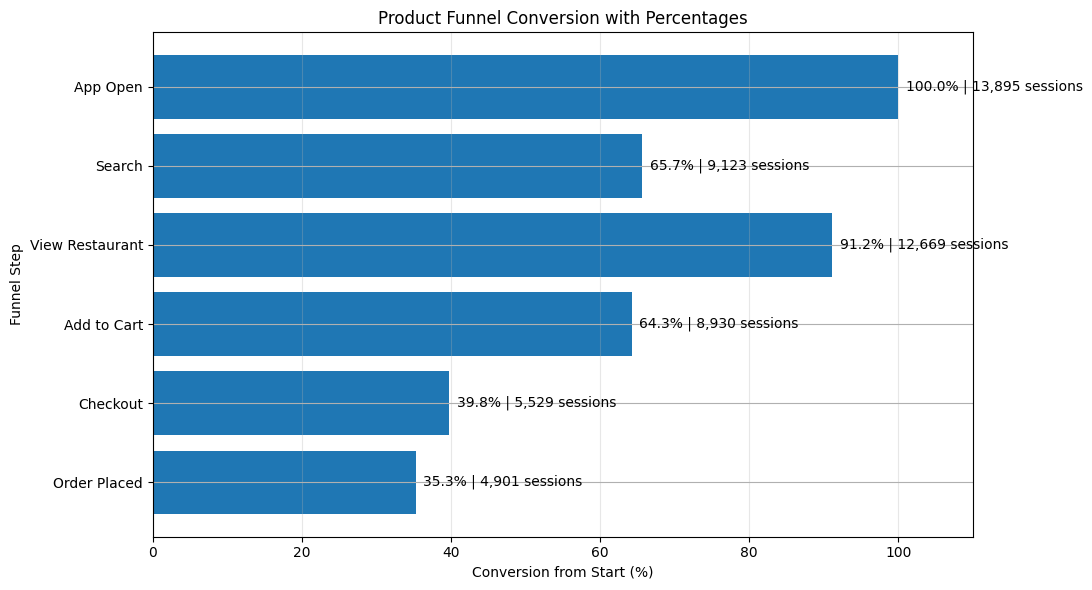

In [ ]:
funnel_chart_pd = funnel_pd.copy()

plt.figure(figsize=(11, 6))

bars = plt.barh(
    funnel_chart_pd["step_name"],
    funnel_chart_pd["conversion_from_start_pct"]
)

plt.xlabel("Conversion from Start (%)")
plt.ylabel("Funnel Step")
plt.title("Product Funnel Conversion with Percentages")
plt.xlim(0, 110)

for bar, sessions, conversion, dropoff in zip(
    bars,
    funnel_chart_pd["sessions_count"],
    funnel_chart_pd["conversion_from_start_pct"],
    funnel_chart_pd["dropoff_from_previous_pct"]
):
    label = f"{conversion:.1f}% | {sessions:,} sessions"

    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center"
    )

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Գրաֆիկի մեկնաբանություն

Գրաֆիկը ցույց է տալիս օգտատերերի անցումը հավելվածի հիմնական փուլերով՝ սկսած հավելվածի բացումից մինչև պատվերի ձևավորում։

Ամենամեծ կորուստը դիտվում է Checkout փուլում, որտեղ պահպանվում է միայն սկզբնական session-ների 39.8%-ը։ Սա ցույց է տալիս, որ վճարման կամ պատվերի հաստատման գործընթացը Product թիմի համար հիմնական ուսումնասիրության կետերից մեկն է։

Նկատվում է նաև, որ View Restaurant փուլի ցուցանիշը (91.2%) գերազանցում է Search փուլի ցուցանիշը (65.7%)։ Սա պայմանավորված է նրանով, որ funnel-ը կառուցված է event coverage-ի հիման վրա և ոչ թե օգտատիրոջ խիստ հաջորդական ճանապարհի (strict funnel)։ Հետևաբար որոշ օգտատերեր կարող են անմիջապես այցելել ռեստորանի էջ՝ առանց search գործողություն կատարելու։

Ընդհանուր առմամբ, միայն 35.3% session-ներն են ավարտվում պատվերի ստեղծմամբ, ինչը հնարավորություն է տալիս գնահատել Product funnel-ի ընդհանուր արդյունավետությունը։

## Order Losses by Lifecycle Stage

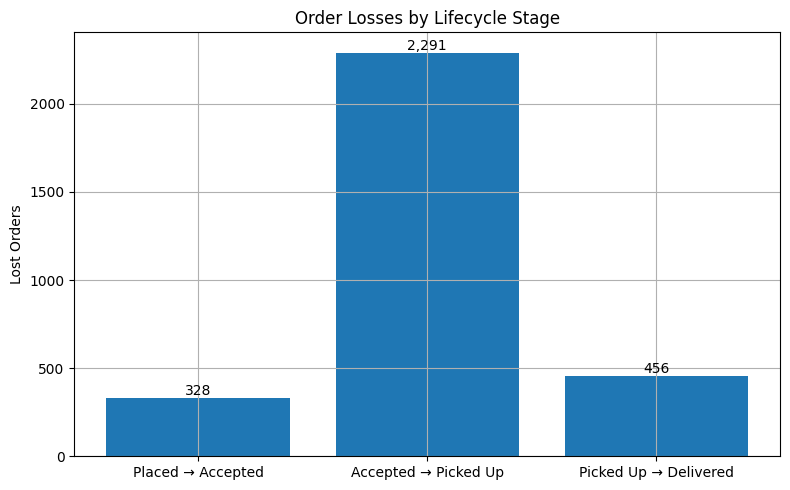

In [ ]:
stages = [
    "Placed → Accepted",
    "Accepted → Picked Up",
    "Picked Up → Delivered"
]

losses = [
    15000 - 14672,
    14672 - 12381,
    12381 - 11925
]

plt.figure(figsize=(8,5))

bars = plt.bar(stages, losses)

plt.title("Order Losses by Lifecycle Stage")
plt.ylabel("Lost Orders")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{int(h):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Գրաֆիկի մեկնաբանություն

Գրաֆիկը ցույց է տալիս պատվերների կորուստները order lifecycle-ի տարբեր փուլերում։

Ամենամեծ կորուստը գրանցվել է Accepted → Picked Up փուլում, որտեղ կորել է 2291 պատվեր։ Սա զգալիորեն գերազանցում է մյուս փուլերի կորուստները և ցույց է տալիս, որ հիմնական օպերացիոն խնդիրը գտնվում է պատվերի ընդունումից հետո՝ մինչև courier-ի կողմից պատվերի վերցնելը։

Placed → Accepted փուլում կորուստը կազմում է ընդամենը 328 պատվեր, ինչը վկայում է, որ ռեստորանների կողմից պատվերների մերժման մակարդակը համեմատաբար ցածր է։

Picked Up → Delivered փուլում կորուստը կազմում է 456 պատվեր, ինչը ցույց է տալիս, որ առաքման գործընթացը համեմատաբար կայուն է։

Այս արդյունքները ենթադրում են, որ օպտիմիզացիոն ջանքերը պետք է կենտրոնացնել courier dispatching և pickup գործընթացների վրա։

## Customer Segmentation by Number of Orders

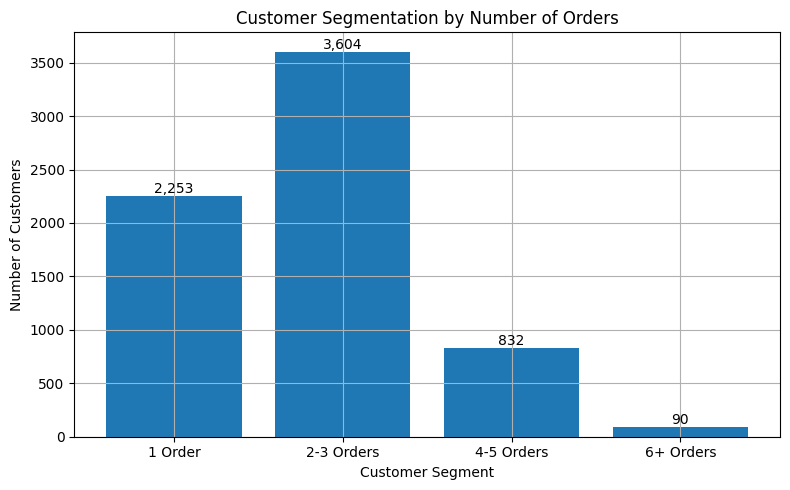

In [ ]:
customer_orders = (
    fact_orders_clean
    .groupBy("customer_id")
    .agg(
        F.countDistinct("order_id").alias("orders_count")
    )
)

customer_segments = (
    customer_orders
    .withColumn(
        "segment",
        F.when(F.col("orders_count") == 1, "1 Order")
         .when(F.col("orders_count").between(2, 3), "2-3 Orders")
         .when(F.col("orders_count").between(4, 5), "4-5 Orders")
         .otherwise("6+ Orders")
    )
    .groupBy("segment")
    .agg(
        F.count("*").alias("customers")
    )
)

segment_pd = customer_segments.toPandas()

segment_order = [
    "1 Order",
    "2-3 Orders",
    "4-5 Orders",
    "6+ Orders"
]

segment_pd["segment"] = pd.Categorical(
    segment_pd["segment"],
    categories=segment_order,
    ordered=True
)

segment_pd = segment_pd.sort_values("segment")

plt.figure(figsize=(8,5))

bars = plt.bar(
    segment_pd["segment"],
    segment_pd["customers"]
)

plt.title("Customer Segmentation by Number of Orders")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

for bar in bars:
    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{int(h):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Գրաֆիկի մեկնաբանություն

Գրաֆիկը ցույց է տալիս հաճախորդների բաշխումը ըստ պատվերների քանակի։

Ամենամեծ խումբը 2–3 պատվեր կատարած հաճախորդներն են (3604 հաճախորդ), ինչը ցույց է տալիս, որ հաճախորդների զգալի մասը վերադառնում է առնվազն մեկ անգամ։

Միևնույն ժամանակ, միայն 90 հաճախորդ է կատարել 6 և ավելի պատվեր, ինչը վկայում է, որ բարձր հավատարմություն ունեցող հաճախորդների բաժինը փոքր է։

Այս արդյունքները ցույց են տալիս, որ Product և Marketing թիմերի համար կարևոր ուղղություն կարող է լինել հաճախորդների երկարաժամկետ պահպանման (retention) բարելավումը և repeat purchase behavior-ի խթանումը։

## Customer Retention Funnel

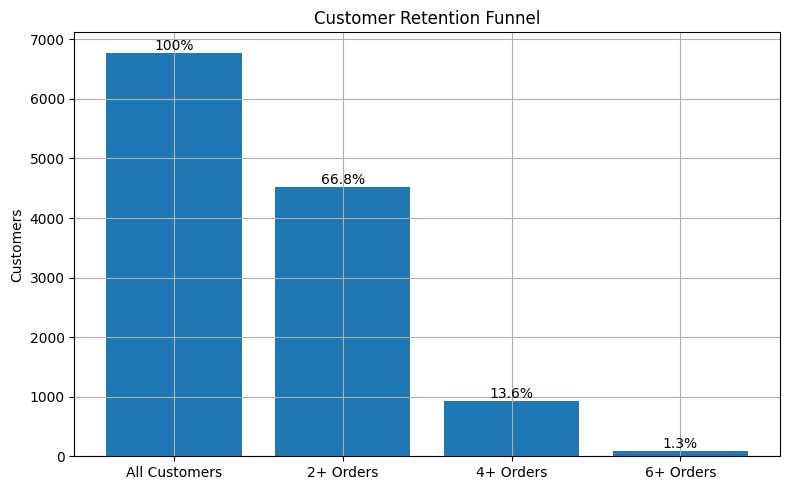

In [ ]:
customer_orders = (
    fact_orders_clean
    .groupBy("customer_id")
    .agg(
        F.countDistinct("order_id").alias("orders_count")
    )
)

total_customers = customer_orders.count()

customers_2plus = (
    customer_orders
    .filter(F.col("orders_count") >= 2)
    .count()
)

customers_4plus = (
    customer_orders
    .filter(F.col("orders_count") >= 4)
    .count()
)

customers_6plus = (
    customer_orders
    .filter(F.col("orders_count") >= 6)
    .count()
)

stages = [
    "All Customers",
    "2+ Orders",
    "4+ Orders",
    "6+ Orders"
]

counts = [
    total_customers,
    customers_2plus,
    customers_4plus,
    customers_6plus
]

percentages = [
    100,
    round(customers_2plus / total_customers * 100, 1),
    round(customers_4plus / total_customers * 100, 1),
    round(customers_6plus / total_customers * 100, 1)
]

plt.figure(figsize=(8,5))

bars = plt.bar(stages, counts)

for bar, pct in zip(bars, percentages):
    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{pct}%",
        ha="center",
        va="bottom"
    )

plt.title("Customer Retention Funnel")
plt.ylabel("Customers")

plt.tight_layout()
plt.show()

Գրաֆիկի մեկնաբանություն

Գրաֆիկը ներկայացնում է հաճախորդների բաշխումը ըստ կատարած պատվերների քանակի։

Ամենամեծ խումբը 2–3 պատվեր կատարած հաճախորդներն են (3604 հաճախորդ), ինչը ցույց է տալիս, որ օգտատերերի զգալի մասը վերադառնում է առնվազն մեկ անգամ և կատարում կրկնակի գնումներ։

Միաժամանակ նկատվում է, որ պատվերների քանակի աճին զուգահեռ հաճախորդների թիվը կտրուկ նվազում է։ Միայն 832 հաճախորդ է կատարել 4–5 պատվեր, իսկ ընդամենը 90 հաճախորդ է հասել 6 և ավելի պատվերի։

Այս արդյունքները ցույց են տալիս, որ հարթակը կարողանում է ապահովել սկզբնական վերադարձ, սակայն բարձր հավատարմություն ունեցող (loyal) հաճախորդների բաժինը փոքր է։ Հետևաբար Product և Marketing թիմերի համար կարևոր ուղղություն կարող է լինել retention ռազմավարությունների և loyalty ծրագրերի զարգացումը՝ հաճախորդների կրկնակի գնումների հաճախականությունը մեծացնելու նպատակով։

## Revenue Heatmap by Weekday and Hour

In [ ]:
orders_heatmap = (
    fact_orders_clean
    .withColumn("hour", F.hour("placed_ts"))
    .withColumn(
        "weekday",
        F.date_format("placed_ts", "E")
    )
    .groupBy("weekday", "hour")
    .agg(
        F.round(F.sum("total"), 2).alias("revenue")
    )
)

heatmap_pd = orders_heatmap.toPandas()

In [ ]:
pivot_df = heatmap_pd.pivot(
    index="weekday",
    columns="hour",
    values="revenue"
)

weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

pivot_df = pivot_df.reindex(weekday_order)
pivot_df = pivot_df.fillna(0)

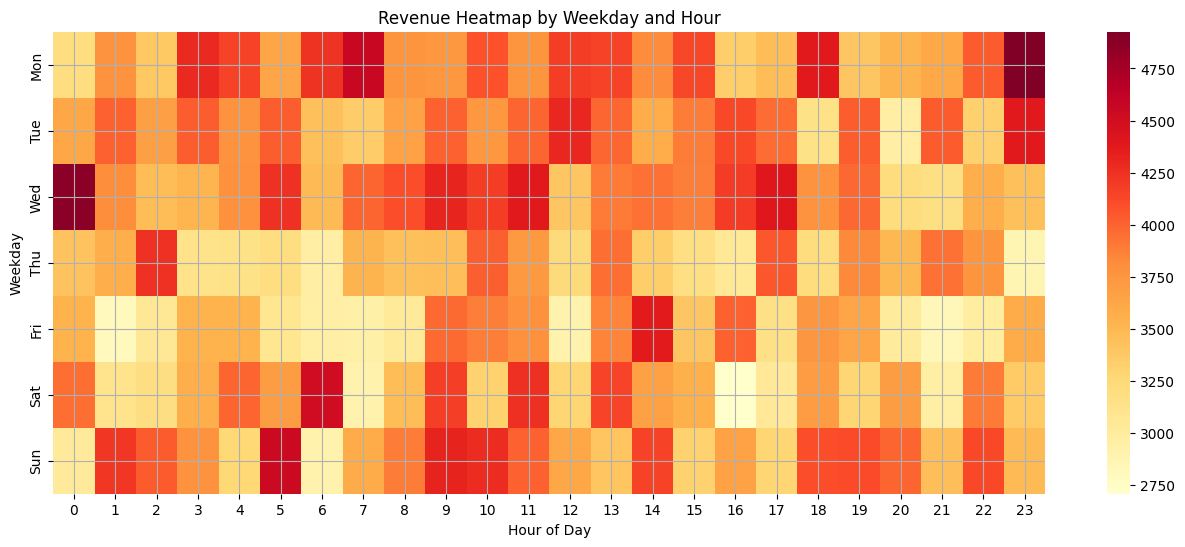

In [ ]:
import seaborn as sns

plt.figure(figsize=(16,6))

sns.heatmap(
    pivot_df,
    annot=False,
    cmap="YlOrRd"
)

plt.title("Revenue Heatmap by Weekday and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday")

plt.show()

Գրաֆիկը ներկայացնում է եկամուտների բաշխումը շաբաթվա օրերի և օրվա ժամերի կտրվածքով։ Յուրաքանչյուր բջիջ ցույց է տալիս տվյալ օրվա և ժամի ընթացքում ստացված ընդհանուր եկամուտը, որտեղ ավելի մուգ գույները համապատասխանում են ավելի բարձր եկամուտներին։

Վերլուծությունը ցույց է տալիս, որ եկամուտները բաշխված են համեմատաբար հավասար ամբողջ շաբաթվա ընթացքում, սակայն նկատվում են մի շարք ժամային և օրային պիկեր։ Առավել բարձր եկամուտներ գրանցվել են հատկապես երկուշաբթի (Mon), չորեքշաբթի (Wed) և շաբաթ (Sat) օրերին որոշ ժամային հատվածներում, որտեղ heatmap-ի բջիջները ունեն առավել ինտենսիվ գունավորում։

Գրաֆիկը ցույց է տալիս, որ պատվերների ակտիվությունը կենտրոնացած չէ միայն ճաշի կամ ընթրիքի ժամերին, այլ բաշխված է օրվա տարբեր հատվածներում, ինչը վկայում է հարթակի կայուն օգտագործման մասին։ Միաժամանակ որոշ ժամային միջակայքերում նկատվում է եկամուտների զգալի աճ, ինչը կարող է պայմանավորված լինել օգտատերերի վարքագծով, մարքեթինգային արշավներով կամ որոշակի ռեստորանների բարձր ակտիվությամբ։

Heatmap-ը հնարավորություն է տալիս բացահայտել ամենաեկամտաբեր ժամանակահատվածները և օգտագործվել հետևյալ որոշումների համար.

- courier-ների հերթափոխերի օպտիմալ պլանավորում,
- մարքեթինգային արշավների ժամանակացույցի բարելավում,
- peak-hour հատուկ առաջարկների մշակում,
- ռեստորանների բեռնվածության գնահատում։

Ընդհանուր առմամբ, գրաֆիկը ցույց է տալիս, որ հարթակի եկամուտները չունեն խիստ արտահայտված սեզոնային կախվածություն օրվա կամ շաբաթվա մակարդակում, սակայն առկա են մի շարք բարձր ակտիվության ժամանակահատվածներ, որոնք կարող են հանդիսանալ հետագա բիզնես վերլուծությունների հիմք։

# AUX

## Միջավայրի նախապատրաստում

### Գրադարանների ներմուծում

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import *
from pyspark.sql.functions import broadcast


### Spark Session-ի ստեղծում

In [ ]:
spark = (
    SparkSession.builder
    .appName("QuickBite_ETL_Pipeline")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/18 13:39:22 WARN Utils: Your hostname, Sergey-PC, resolves to a loopback address: 127.0.1.1; using 192.168.0.108 instead (on interface wlo1)
26/06/18 13:39:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/18 13:39:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Տվյալների ներբեռնում և սխեմաների սահմանում

Այս բաժնում իրականացվում է նախագծի սկզբնական փուլերից մեկը՝ տվյալների ներբեռնումը և դրանց կառուցվածքի (schema) սահմանումը։

Քանի որ առաջադրանքի նկարագրության մեջ բոլոր աղյուսակների դաշտերը և տվյալների տիպերը նախապես հայտնի են, schema inference-ի փոխարեն օգտագործվում են ձեռքով սահմանված սխեմաներ (Explicit Schemas)։

Սույն բաժնում սահմանվելու են բոլոր յոթ աղյուսակների սխեմաները, որից հետո տվյալները կներբեռնվեն Spark DataFrame-ների մեջ։

### app_events աղյուսակի սխեմայի սահմանում

Այս աղյուսակը պարունակում է օգտատերերի գործողությունները QuickBite բջջային հավելվածում։

Յուրաքանչյուր գրառում ներկայացնում է հավելվածում կատարված մեկ գործողություն, օրինակ՝ հավելվածի բացում, ռեստորանի դիտում, ապրանքի ավելացում զամբյուղ կամ պատվերի ձևակերպում։

In [ ]:
app_events_schema = StructType([
    StructField("event_id", StringType(), True),
    StructField("user_id", StringType(), True),
    StructField("session_id", StringType(), True),
    StructField("event_type", StringType(), True),
    StructField("screen", StringType(), True),
    StructField("device", StringType(), True),
    StructField("app_version", StringType(), True),
    StructField("ts", TimestampType(), True),
    StructField("city", StringType(), True)
])

### orders աղյուսակի սխեմայի սահմանում

Այս աղյուսակը պարունակում է QuickBite հարթակում կատարված պատվերների վերաբերյալ ամբողջ տեղեկատվությունը։

Այն հանդիսանում է համակարգի հիմնական գործառնական աղյուսակներից մեկը և հետագայում կօգտագործվի վերլուծական fact աղյուսակի կառուցման համար։

In [ ]:
orders_schema = StructType([
    StructField("order_id", StringType(), True),
    StructField("customer_id", StringType(), True),
    StructField("restaurant_id", StringType(), True),
    StructField("courier_id", StringType(), True),
    StructField("status", StringType(), True),
    StructField("subtotal", DoubleType(), True),
    StructField("discount", DoubleType(), True),
    StructField("total", DoubleType(), True),
    StructField("promo_code", StringType(), True),
    StructField("placed_ts", TimestampType(), True),
    StructField("accepted_ts", TimestampType(), True),
    StructField("picked_up_ts", TimestampType(), True),
    StructField("delivered_ts", TimestampType(), True),
    StructField("rating", DoubleType(), True),
    StructField("city", StringType(), True)
])

### payments աղյուսակի սխեմայի սահմանում

Այս աղյուսակը պարունակում է պատվերների վճարման վերաբերյալ տեղեկատվությունը։

Այն հնարավորություն է տալիս վերլուծել վճարումների հաջողությունը, ձախողումները և վերադարձված գումարները։

In [ ]:
payments_schema = StructType([
    StructField("payment_id", StringType(), True),
    StructField("order_id", StringType(), True),
    StructField("method", StringType(), True),
    StructField("amount", DoubleType(), True),
    StructField("status", StringType(), True),
    StructField("ts", TimestampType(), True),
    StructField("gateway_ref", StringType(), True)
])

### restaurants աղյուսակի սխեմայի սահմանում

Այս աղյուսակը պարունակում է հարթակում գրանցված ռեստորանների տեղեկությունները։

Տվյալները ներառում են ռեստորանի գտնվելու վայրը, խոհանոցի տեսակը, հասանելիության կարգավիճակը և միջին գնահատականը։

In [ ]:
restaurants_schema = StructType([
    StructField("restaurant_id", StringType(), True),
    StructField("name", StringType(), True),
    StructField("cuisine", StringType(), True),
    StructField("city", StringType(), True),
    StructField("is_available", BooleanType(), True),
    StructField("avg_prep_minutes", IntegerType(), True),
    StructField("rating_avg", DoubleType(), True),
    StructField("signup_date", DateType(), True)
])

### couriers աղյուսակի սխեմայի սահմանում

Այս աղյուսակը պարունակում է առաքիչների վերաբերյալ տվյալները։

Այստեղ պահպանվում են առաքիչի նույնացուցիչը, տրանսպորտային միջոցի տեսակը, աշխատանքի ժամերը և ակտիվության կարգավիճակը։

In [ ]:
couriers_schema = StructType([
    StructField("courier_id", StringType(), True),
    StructField("name", StringType(), True),
    StructField("vehicle", StringType(), True),
    StructField("city", StringType(), True),
    StructField("shift_start_hour", IntegerType(), True),
    StructField("shift_end_hour", IntegerType(), True),
    StructField("is_active", BooleanType(), True)
])

### marketing_campaigns աղյուսակի սխեմայի սահմանում

Այս աղյուսակը պարունակում է մարքեթինգային արշավների վերաբերյալ տեղեկատվությունը։

Այն ներառում է արշավի ալիքը, թիրախային լսարանը, ժամանակային միջակայքը և բյուջեն։

In [ ]:
marketing_campaigns_schema = StructType([
    StructField("campaign_id", StringType(), True),
    StructField("name", StringType(), True),
    StructField("channel", StringType(), True),
    StructField("target_segment", StringType(), True),
    StructField("start_ts", TimestampType(), True),
    StructField("end_ts", TimestampType(), True),
    StructField("budget", DoubleType(), True)
])

### promo_codes աղյուսակի սխեմայի սահմանում

Այս աղյուսակը պարունակում է զեղչային կոդերի վերաբերյալ տեղեկատվությունը։

Յուրաքանչյուր կոդ կապված է որոշակի մարքեթինգային արշավի հետ և ունի օգտագործման սահմանափակումներ ու գործողության ժամկետ։

In [ ]:
promo_codes_schema = StructType([
    StructField("code", StringType(), True),
    StructField("campaign_id", StringType(), True),
    StructField("discount_pct", DoubleType(), True),
    StructField("max_uses", IntegerType(), True),
    StructField("current_uses", IntegerType(), True),
    StructField("valid_from", TimestampType(), True),
    StructField("valid_to", TimestampType(), True)
])

## Տվյալների ներբեռնում Spark DataFrame-ների մեջ

Սույն բաժնում նախապես սահմանված սխեմաների միջոցով CSV ֆայլերը ներբեռնվում են Spark DataFrame-ների մեջ։

Explicit Schema-ների կիրառումը թույլ է տալիս ապահովել տվյալների ճիշտ տիպավորումը, բարձրացնել ընթերցման արագությունը և բացառել ավտոմատ schema inference-ի հետևանքով առաջացող հնարավոր սխալները։

Ներբեռնված DataFrame-ները կօգտագործվեն նախագծի հաջորդ փուլերում՝ տվյալների ուսումնասիրության, մաքրման, ագրեգացիաների և վերլուծությունների իրականացման համար։

In [ ]:
DATA_PATH = "/home/sergey/Desktop/BigData_Final/data"

paths = {
    "app_events": f"{DATA_PATH}/app_events.csv",
    "orders": f"{DATA_PATH}/orders.csv",
    "payments": f"{DATA_PATH}/payments.csv",
    "restaurants": f"{DATA_PATH}/restaurants.csv",
    "couriers": f"{DATA_PATH}/couriers.csv",
    "marketing_campaigns": f"{DATA_PATH}/marketing_campaigns.csv",
    "promo_codes": f"{DATA_PATH}/promo_codes.csv"
}

### CSV ֆայլերի ներբեռնում

Յուրաքանչյուր CSV ֆայլ ներբեռնվում է համապատասխան schema-ի միջոցով՝ ստանալով Spark DataFrame։

In [ ]:
app_events_raw = (
    spark.read
    .option("header", True)
    .schema(app_events_schema)
    .csv(paths["app_events"])
)

orders_raw = (
    spark.read
    .option("header", True)
    .schema(orders_schema)
    .csv(paths["orders"])
)

payments_raw = (
    spark.read
    .option("header", True)
    .schema(payments_schema)
    .csv(paths["payments"])
)

restaurants_raw = (
    spark.read
    .option("header", True)
    .schema(restaurants_schema)
    .csv(paths["restaurants"])
)

couriers_raw = (
    spark.read
    .option("header", True)
    .schema(couriers_schema)
    .csv(paths["couriers"])
)

marketing_campaigns_raw = (
    spark.read
    .option("header", True)
    .schema(marketing_campaigns_schema)
    .csv(paths["marketing_campaigns"])
)

promo_codes_raw = (
    spark.read
    .option("header", True)
    .schema(promo_codes_schema)
    .csv(paths["promo_codes"])
)

In [ ]:
raw_tables = {
    "app_events": app_events_raw,
    "orders": orders_raw,
    "payments": payments_raw,
    "restaurants": restaurants_raw,
    "couriers": couriers_raw,
    "marketing_campaigns": marketing_campaigns_raw,
    "promo_codes": promo_codes_raw
}

for table_name, df in raw_tables.items():
    print(f"{table_name}: {df.count()} տող, {len(df.columns)} սյունակ")

app_events: 80000 տող, 9 սյունակ
orders: 15000 տող, 15 սյունակ
payments: 14827 տող, 7 սյունակ
restaurants: 500 տող, 8 սյունակ
couriers: 300 տող, 7 սյունակ
marketing_campaigns: 50 տող, 7 սյունակ
promo_codes: 210 տող, 7 սյունակ


### Տվյալների նախնական ուսումնասիրություն

Տվյալների ներբեռնումից հետո անհրաժեշտ է իրականացնել նախնական ուսումնասիրություն։

Այս փուլում ուսումնասիրվում են աղյուսակների չափերը, կառուցվածքը և բովանդակությունը՝ տվյալների ընդհանուր պատկերը հասկանալու և հետագա վերլուծության համար նախապատրաստվելու նպատակով։

Նախնական ուսումնասիրությունը թույլ է տալիս վաղ փուլում հայտնաբերել հնարավոր խնդիրներ, ինչպիսիք են.

- բացակայող արժեքները,
- սխալ տվյալների տիպերը,
- անսպասելի արժեքները,
- կրկնվող գրառումները,
- աղյուսակների միջև անհամապատասխանությունները։

### Աղյուսակների չափեր

Այս ենթաբաժնում ներկայացվում է յուրաքանչյուր աղյուսակի տողերի և սյունակների քանակը։

In [ ]:
overview_df = spark.createDataFrame(
    [
        ("app_events", app_events_raw.count(), len(app_events_raw.columns)),
        ("orders", orders_raw.count(), len(orders_raw.columns)),
        ("payments", payments_raw.count(), len(payments_raw.columns)),
        ("restaurants", restaurants_raw.count(), len(restaurants_raw.columns)),
        ("couriers", couriers_raw.count(), len(couriers_raw.columns)),
        ("marketing_campaigns", marketing_campaigns_raw.count(), len(marketing_campaigns_raw.columns)),
        ("promo_codes", promo_codes_raw.count(), len(promo_codes_raw.columns))
    ],
    ["Աղյուսակ", "Տողերի_քանակ", "Սյունակների_քանակ"]
)

overview_df.show(truncate=False)

+-------------------+------------+-----------------+
|Աղյուսակ           |Տողերի_քանակ|Սյունակների_քանակ|
+-------------------+------------+-----------------+
|app_events         |80000       |9                |
|orders             |15000       |15               |
|payments           |14827       |7                |
|restaurants        |500         |8                |
|couriers           |300         |7                |
|marketing_campaigns|50          |7                |
|promo_codes        |210         |7                |
+-------------------+------------+-----------------+



### Աղյուսակների կառուցվածքի ուսումնասիրություն

Այս ենթաբաժնում ստուգվում է ներբեռնված DataFrame-ների կառուցվածքը և դաշտերի տվյալների տիպերը։

In [ ]:
for table_name, df in raw_tables.items():
    print("=" * 80)
    print(f"Աղյուսակ՝ {table_name}")
    print("=" * 80)
    df.printSchema()

Աղյուսակ՝ app_events
root
 |-- event_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- session_id: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- screen: string (nullable = true)
 |-- device: string (nullable = true)
 |-- app_version: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- city: string (nullable = true)

Աղյուսակ՝ orders
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- restaurant_id: string (nullable = true)
 |-- courier_id: string (nullable = true)
 |-- status: string (nullable = true)
 |-- subtotal: double (nullable = true)
 |-- discount: double (nullable = true)
 |-- total: double (nullable = true)
 |-- promo_code: string (nullable = true)
 |-- placed_ts: timestamp (nullable = true)
 |-- accepted_ts: timestamp (nullable = true)
 |-- picked_up_ts: timestamp (nullable = true)
 |-- delivered_ts: timestamp (nullable = true)
 |-- rating: double (nullable = true)
 |-- ci

### Առաջին տողերի ուսումնասիրություն

Այս ենթաբաժնում ցուցադրվում են յուրաքանչյուր աղյուսակի առաջին գրառումները՝ տվյալների բովանդակությանը ծանոթանալու նպատակով։

In [ ]:
for table_name, df in raw_tables.items():
    print("\n")
    print("=" * 80)
    print(f"Աղյուսակ՝ {table_name}")
    print("=" * 80)

    df.show(5, truncate=False)



Աղյուսակ՝ app_events
+---------+-------+----------+-----------+--------+-------+-----------+--------------------------+----+
|event_id |user_id|session_id|event_type |screen  |device |app_version|ts                        |city|
+---------+-------+----------+-----------+--------+-------+-----------+--------------------------+----+
|E00000001|U000916|S0015903  |app_open   |home    |ios    |3.8.1      |2026-05-13 11:58:32.110615|YVN |
|E00000002|U000438|S0016264  |app_open   |checkout|ios    |4.0.0      |2026-05-06 21:08:16.584905|YVN |
|E00000003|U004135|S0000292  |app_open   |cart    |ios    |3.9.1      |2026-04-25 19:31:23.287834|VND |
|E00000004|U007472|S0001223  |search     |cart    |web    |4.0.2      |2026-05-23 08:59:06.698859|GYU |
|E00000005|U003696|S0014988  |add_to_cart|home    |android|3.8.1      |2026-04-05 21:46:48.935295|KPN |
+---------+-------+----------+-----------+--------+-------+-----------+--------------------------+----+
only showing top 5 rows


Աղյուսակ՝ order